<h1 style="text-align: center;">Project Title: AI Driven Risk Intelligence for 2026 Interpol Fugitives</h1>


### Course and Section: CS610 Applied Machine Learning (G1)

#### Team Members: 
Cathy CHU Shan-hui <br>
Dian Farah BINTE RIDUAN <br>
GOH See Ting <br>
KARANAM Akshit <br>
TAN Wenying Audrey 

<br>

## 1 Create new environment

## Installed packages

## Import libraries and packages

In [2]:
import pandas as pd
import numpy as np

import json
import os
import requests
from io import StringIO  # Add this import
from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx

from transformers import pipeline
import torch
import pandas as pd
from tqdm.auto import tqdm   # progress bar
import spacy

import ast
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              roc_auc_score, precision_score,
                              recall_score, f1_score, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               IsolationForest)
from sklearn.svm import SVC

## 2 DATA PREPARATION

### Load data

In [3]:
# Load the data back
df_cleaned = pd.read_csv('data/crime_analysis_results.csv')
df_cleaned.head()

,id,hairColor,height,eyeColor,name,birth_date,sanctions,program_ids,first_seen,last_seen,...,Label,GENDER,Address,age_at_first_seen,days_since_last_change,age_today,age_at_last_seen,sanctions_clean,address,label
0,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Russia,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5,"""participation in the activity of a terrorist ...",kofarnikhon town,russia
1,NK-224TRezPqwzhQZ37exWxtX,OTHD,NaN,OTHD,SANAVBARI NIKITENKO,1992-06-28,"""participation in the activity of a terrorist ...",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Tajikistan,F,KOFARNIKHON TOWN,31.7,114.0,33.0,32.5,"""participation in the activity of a terrorist ...",kofarnikhon town,tajikistan
2,NK-22baaNEkbgBeZokNLmpaKd,NaN,NaN,NaN,DZHAMBULAT GALIMOV,1989-01-05,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Russia,M,DAGESTAN REPUBLIC,35.2,114.0,37.0,37.0,participation in illegal armed formation,dagestan republic,russia
3,NK-282timUs47w9otBkgPN6hw,BLA,1.75,BLA,KHAVA EFENDIEVA,1982-05-24,Participation in illegal armed formation,INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,Russia,F,"GROZNY, CHECHEN REPUBLIC",41.8,114.0,43.0,42.6,participation in illegal armed formation,"grozny, chechen republic",russia
4,NK-2Ld7pewCoLeyspMtVCMMMo,NaN,NaN,NaN,JIAN XIA,1977-07-13,"""1) Murder\n2) Manslaughter\n3) Aggravated theft""",INTERPOL-RN,2024-03-04 17:09:51,2026-01-14 09:27:01,...,China,M,LIAONING,46.6,114.0,48.0,47.5,"""1) murder\n2) manslaughter\n3) aggravated theft""",liaoning,china


In [ ]:
df_cleaned.dtypes

id                            str
hairColor                     str
height                    float64
eyeColor                      str
name                          str
birth_date                    str
sanctions                     str
program_ids                   str
first_seen                    str
last_seen                     str
last_change                   str
Code                          str
Label                         str
GENDER                        str
Address                       str
age_at_first_seen         float64
days_since_last_change    float64
age_today                 float64
age_at_last_seen          float64
sanctions_clean               str
address                       str
label                         str
dtype: object

In [ ]:
df_cleaned['first_seen'].drop_duplicates().sort_values()

4942    2024-03-03 18:27:01
1086    2024-03-04 00:27:01
178     2024-03-04 09:27:18
0       2024-03-04 17:09:51
3896    2024-03-05 12:13:17
               ...         
7054    2025-12-23 00:28:48
7050    2025-12-24 09:27:01
7027    2025-12-26 18:27:01
3820    2025-12-29 09:27:01
913                     NaN
Name: first_seen, Length: 346, dtype: str

Check first_seen to extract news from 2024 to 2026

In [ ]:
# drop duplicate cols.
columns_to_drop = ['Address','sanctions', 'Label']
df_cleaned = df_cleaned.drop(columns_to_drop, axis=1)

### LANGUAGE DETECTION

Checking English rows

In [ ]:
print(df_cleaned.shape)
print(df_cleaned.columns.tolist())
df_cleaned['sanctions_clean'].head(10)

(7057, 19)
['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label']


0    "participation in the activity of a terrorist ...
1    "participation in the activity of a terrorist ...
2             participation in illegal armed formation
3             participation in illegal armed formation
4    "1) murder\n2) manslaughter\n3) aggravated theft"
5    assaulting a public officer, impeding official...
6    murder/accomplice, manslaughter accomplice,  k...
7    murder/accomplice, manslaughter accomplice,  k...
8    participation in an illegal armed formation - ...
9             participation in illegal armed formation
Name: sanctions_clean, dtype: str

Checking non-English rows

In [221]:
from langdetect import detect

def detect_language(text):
    try:
        if not isinstance(text, str) or len(text.strip()) < 5:
            return 'unknown'
        return detect(text)
    except:
        return 'unknown'

df_cleaned['detected_lang'] = df_cleaned['sanctions_clean'].apply(detect_language)
print(df_cleaned['detected_lang'].value_counts())

detected_lang
en         4353
es         1256
it          363
de          331
pt          181
fr          172
da          112
ca           48
unknown      45
fi           36
no           35
pl           15
ro           14
tl           13
af           13
so           13
cy           12
et           12
nl           11
hu            7
sq            5
sl            3
sv            2
id            2
sk            2
hr            1
Name: count, dtype: int64


Total records: 7,057

English (no translation needed): 4,374 (62.0%) 

Non-English (translation needed): 2,683 (38.0%) across 25 languages:\
  Spanish    : 1,266 (17.9%) \
  Italian    :   343  (4.9%)\
  German     :   335  (4.7%)\
  French     :   176  (2.5%)\
  Portuguese :   176  (2.5%)\
  Danish     :   113  (1.6%)\
  Others     :   274  (3.9%)\
  Unknown    :    45  (0.6%)

38.0% of records contain non-English crime descriptions spanning 25 languages, representing a substantial portion of the dataset that would be inaccessible to English-only NLP models without translation. 

Spanish alone accounts for 17.9% of all records, with Italian, German, French, and Portuguese contributing a further 15.6% collectively. 

  All non-English text was translated to English using Google Translate via the deep-translator library prior to downstream processing, ensuring consistent language representation across the full dataset.\
  45 records with undetected language were treated as English given their negligible proportion (0.6%) and likely short or ambiguous text content.

What we will do next:

translate non-English rows → run TRANSFORMER > NER → LDA

### PERFORM TRANSLATION

In [222]:
!pip install deep-translator langdetect

/opt/miniconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=67959) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()
python(77939) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:
from deep_translator import GoogleTranslator

def translate_if_needed(row):
    if row['detected_lang'] == 'en' or row['detected_lang'] == 'unknown':
        return row['sanctions_clean']
    try:
        text = str(row['sanctions_clean']).strip()
        if len(text) < 5:
            return text
        return GoogleTranslator(source='auto', target='en').translate(text)
    except Exception as e:
        return row['sanctions_clean']


results = []
for i, row in df_cleaned.iterrows():
    results.append(translate_if_needed(row))

df_cleaned['sanctions_translated'] = results

# Sanity check
non_eng = df_cleaned[df_cleaned['detected_lang'] != 'en'].head(10)
for i, row in non_eng.iterrows():
    print(f"\nOriginal  ({row['detected_lang']}): {row['sanctions_clean'][:100]}")
    print(f"Translated: {row['sanctions_translated'][:100]}")

Loading translation result

In [ ]:
sanctions_translated = pd.read_csv('data/crime_analysis_results_translation.csv')

print(f"Rows    : {len(sanctions_translated):,}")
print(f"Columns : {sanctions_translated.columns.tolist()}")
print(f"\nSample sanctions_translated:")
print(sanctions_translated['sanctions_translated'].head(3).tolist())

Rows    : 7,057
Columns : ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated']

Sample sanctions_translated:
['"participation in the activity of a terrorist organization; participation in the activity of an illegal armed formation"', '"participation in the activity of a terrorist organization; participation in the activity of an illegal armed formation"', 'participation in illegal armed formation']


## 3. UNSUPERVISED CRIME CATEGORIZATION

## Perform Transformer

BERT is better than Spacy for complex context and has high accuracy.

We have little to no labeled data, and categories are dynamic so we used zero-shot (LLM based) instead of legal bert (fined-tuned)

## Transformer: multi-label

═══════════════════════════════════════════════════════════════════
BART ZERO-SHOT CLASSIFICATION — MULTI-LABEL VERSION
═══════════════════════════════════════════════════════════════════

For a compliance risk screening system, it's dangerous to miss a co-occurring crime type (e.g. weapons, trafficking) that could mean a high-risk individual is under-flagged.

The code below saves scores for all 8 crime labels per entry, keeping any label that scores >= 0.3 (30% confidence threshold).

This gives us a richer, multi-label view of each sanctions entry, which is more appropriate for compliance screening.

Example of improvement:

Single label: detected_crime_type = "terrorism" (only)

Multi label:  score_terrorism=0.87, score_weapons=0.45 (both flagged)


In [ ]:
# ── 1. Device detection ───────────────────────────────────────────
device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU (no GPU found)'}")

# ── 2. Load model ─────────────────────────────────────────────────
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device,
)

crime_labels = [
    "terrorism",
    "homicide",
    "financial crime",
    "cyber crime",
    "narcotics",
    "assault",
    "weapons"
]

# ── 3. Deduplicate texts before classifying ───────────────────────
texts_series = df_cleaned['sanctions_translated'].fillna("").astype(str).str.strip()

unique_texts  = texts_series.unique().tolist()
valid_texts   = [t for t in unique_texts if len(t) >= 5]
invalid_texts = [t for t in unique_texts if len(t) < 5]

print(f"Total rows      : {len(df_cleaned):,}")
print(f"Unique texts    : {len(unique_texts):,}  ← only classifying these")
print(f"Skipping (empty): {len(invalid_texts):,}")

# ── 4. Batch classify — save ALL label scores ─────────────────────
# CHANGE: results_map now stores a dict of {label: score} per text
# instead of just (top_label, top_score)
BATCH_SIZE = 16
results_map = {}

for i in range(0, len(valid_texts), BATCH_SIZE):
    batch = valid_texts[i : i + BATCH_SIZE]
    try:
        outputs = classifier(
            batch,
            candidate_labels=crime_labels,
            multi_label=True,
            batch_size=BATCH_SIZE,
        )
        for text, result in zip(batch, outputs):
            # CHANGE: save all labels scoring >= 0.3
            results_map[text] = {
                label: round(score, 4)
                for label, score in zip(result['labels'], result['scores'])
                if score >= 0.3
            }
    except Exception as e:
        print(f"⚠️  Batch {i//BATCH_SIZE} failed ({e}), falling back to single...")
        for text in batch:
            try:
                result = classifier(text, candidate_labels=crime_labels, multi_label=True)
                results_map[text] = {
                    label: round(score, 4)
                    for label, score in zip(result['labels'], result['scores'])
                    if score >= 0.3
                }
            except:
                results_map[text] = {}

# Empty/invalid texts get empty dict
for text in invalid_texts:
    results_map[text] = {}

# ── 5. Map results back to dataframe ──────────────────────────────
# CHANGE: create one score column per crime type
# e.g. score_terrorism, score_homicide, score_financial_crime etc.
for label in crime_labels:
    col_name = f'score_{label.replace(" ", "_")}'
    df_cleaned[col_name] = texts_series.map(
        lambda x, l=label: results_map.get(x, {}).get(l, 0.0)
    )

# Primary label = highest scoring crime type
df_cleaned['detected_crime_type'] = texts_series.map(
    lambda x: max(
        results_map.get(x, {'Unknown': 0.0}),
        key=results_map.get(x, {'Unknown': 0.0}).get
    ) if results_map.get(x) else 'Unknown'
)

# Primary confidence = score of the top label
df_cleaned['confidence_scores'] = texts_series.map(
    lambda x: max(results_map.get(x, {'Unknown': 0.0}).values())
    if results_map.get(x) else 0.0
)

# ── 6. Sanity check ───────────────────────────────────────────────
print(f"\nPrimary crime type distribution:")
print(df_cleaned['detected_crime_type'].value_counts())

print(f"\nLow confidence (<0.5): {(df_cleaned['confidence_scores'] < 0.5).sum():,} rows")

# Show multi-label example — entries flagged for 2+ crime types
score_cols = [f'score_{l.replace(" ", "_")}' for l in crime_labels]
df_cleaned['num_crime_types'] = (df_cleaned[score_cols] >= 0.3).sum(axis=1)
print(f"\nEntries flagged for multiple crime types:")
print(df_cleaned['num_crime_types'].value_counts().sort_index())

Device: CPU (no GPU found)


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Total rows      : 7,057
Unique texts    : 2,937  ← only classifying these
Skipping (empty): 6

Primary crime type distribution:
detected_crime_type
armed formation    2098
terrorism          1553
homicide           1434
financial crime     451
Unknown             434
sexual crime        414
narcotics           390
assault             283
Name: count, dtype: int64

Low confidence (<0.5): 596 rows

Entries flagged for multiple crime types:
num_crime_types
0     434
1    2215
2    3244
3    1051
4     103
5       8
6       1
7       1
Name: count, dtype: int64


50% of entries involve 2 or more crime types. If keeping single-label only, half dataset would have been under-flagged for compliance screening.

## Saving BART result


In [192]:
df_cleaned.to_csv('data/crime_analysis_results_bart.csv', index=False)
print(f"Shape: {df_cleaned.shape}")
print(f"Columns: {df_cleaned.columns.tolist()}")

Shape: (7057, 33)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_narcotics', 'score_assault', 'score_sexual_crime', 'score_armed_formation', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str']


## 3.2 Perform NER

In [193]:
import re

nlp = spacy.load("en_core_web_lg")

def process_interpol_data(text):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return []
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        if ent.label_ not in ["PERSON", "ORG", "GPE"]:
            continue
        clean = ent.text.strip()
        # Filter out: numbers, legal codes, very short strings, punctuation-heavy strings
        if len(clean) < 3:
            continue
        if re.search(r'\d', clean):  # skip anything containing digits
            continue
        if re.search(r'[(){}\[\]]', clean):  # skip anything with brackets
            continue
        entities.append((clean, ent.label_))
    return entities

# ── Run NER on TRANSLATED text
df_cleaned['entities'] = df_cleaned['sanctions_translated'].apply(process_interpol_data)

# ── Sanity check 
has_entities = df_cleaned['entities'].apply(lambda x: isinstance(x, list) and len(x) > 0)
print(f"Rows with entities : {has_entities.sum():,} / {len(df_cleaned):,}")

print(f"\nSample output:")
for i, row in df_cleaned[has_entities].head(50).iterrows():
    print(f"  Row {i}: {row['entities'][:20]}")

# ── Save entities as string for CSV compatibility
df_cleaned['entities_str'] = df_cleaned['entities'].apply(str)

Rows with entities : 140 / 7,057

Sample output:
  Row 200: [('iraq', 'GPE')]
  Row 201: [('iraq', 'GPE')]
  Row 245: [('canada', 'GPE')]
  Row 336: [('u.s.', 'GPE'), ('the united states', 'GPE')]
  Row 337: [('u.s.', 'GPE'), ('the united states', 'GPE')]
  Row 364: [('india', 'GPE')]
  Row 365: [('montenegro', 'GPE')]
  Row 372: [('iraq', 'GPE')]
  Row 373: [('iraq', 'GPE')]
  Row 401: [('india', 'GPE'), ('india', 'GPE')]
  Row 438: [('denmark', 'GPE'), ('denmark', 'GPE')]
  Row 445: [('abd', 'PERSON')]
  Row 454: [('india', 'GPE')]
  Row 456: [('united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('united states', 'GPE'), ('the united states', 'GPE')]
  Row 457: [('united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('the united states', 'GPE'), ('united states', 'GPE'), ('the united states', 'GPE')]
  Row 462: [('niamey', 'GPE'), ('niger', 'GPE'), ('mali', 'GPE'), ('robert fowler', 'PERSON'

Only 2% of rows have entities.

#### Saving NER

In [194]:
df_cleaned.to_csv('data/crime_analysis_results_bart_ner_2.csv', index=False)
print(f"Shape: {df_cleaned.shape}")
print(f"Columns: {df_cleaned.columns.tolist()}")

Shape: (7057, 33)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_narcotics', 'score_assault', 'score_sexual_crime', 'score_armed_formation', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str']


### Loading

In [195]:
df_ready = pd.read_csv('data/crime_analysis_results_bart_ner.csv')
print(f"Shape: {df_ready.shape}")
print(f"Columns: {df_ready.columns.tolist()}")

Shape: (7057, 33)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str']


## 3.3 LDA

LDA gives topic-word distributions, not crime labels or cluster assignments. LDA surfaced 6 latent topics whose top terms correspond closely to our predefined crime labels, validating our BART label taxonomy before clustering.

In [215]:
!pip install gensim

/opt/miniconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=67959) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()
python(64797) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## LDA: Load data & Imports

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import gensim
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# ── 1. Load data ──────────────────────────────────────────────────────────────
print(f"Shape: {df_ready.shape}")
print(f"Sample text:\n{df_ready['sanctions_translated'].head(5)}")

Shape: (7057, 33)
Sample text:
0    "participation in the activity of a terrorist ...
1    "participation in the activity of a terrorist ...
2             participation in illegal armed formation
3             participation in illegal armed formation
4    "1) murder\n2) manslaughter\n3) aggravated theft"
Name: sanctions_translated, dtype: str


In [213]:
import gensim
print(f"Gensim version: {gensim.__version__}")

Gensim version: 4.4.0


## LDA: Lemmatization

In [205]:
import spacy
nlp = spacy.load("en_core_web_lg")

def lemmatize_doc(doc):
    return " ".join([
        token.lemma_.lower()
        for token in doc
        if not token.is_punct
        and not token.is_space
        and not token.like_num
    ])

# ── Batch processing with nlp.pipe() ─────────────────────────────
texts = df_ready['sanctions_translated'].fillna("").astype(str).tolist()

results = []
for doc in nlp.pipe(texts, disable=["ner", "parser"], batch_size=64):
    results.append(lemmatize_doc(doc))

df_ready['sanctions_lemmatized'] = results

# ── Save lemmatized results immediately ───────────────────────────
df_ready.to_csv('data/crime_analysis_results_lemmatized.csv', index=False)
print(f"Saved lemmatized results: {len(df_ready):,} rows")

# ── Sanity check ──────────────────────────────────────────────────
print("\nSample comparison:")
for i in range(5):
    print(f"\nOriginal  : {df_ready['sanctions_translated'].iloc[i][:100]}")
    print(f"Lemmatized: {df_ready['sanctions_lemmatized'].iloc[i][:100]}")

Saved lemmatized results: 7,057 rows

Sample comparison:

Original  : "participation in the activity of a terrorist organization; participation in the activity of an ille
Lemmatized: participation in the activity of a terrorist organization participation in the activity of an illega

Original  : "participation in the activity of a terrorist organization; participation in the activity of an ille
Lemmatized: participation in the activity of a terrorist organization participation in the activity of an illega

Original  : participation in illegal armed formation
Lemmatized: participation in illegal armed formation

Original  : participation in illegal armed formation
Lemmatized: participation in illegal armed formation

Original  : "1) murder
2) manslaughter
3) aggravated theft"
Lemmatized: murder manslaughter aggravate theft


##### Check frequncy of stop words

Before running LDA, we identify domain-specific stopwords to remove from the corpus. Generic crime descriptors (e.g. "criminal", 
"illegal", "activity") and legal boilerplate (e.g. "act", "section","pursuant") appear so frequently across all topics that they reduce LDA's ability to distinguish meaningful crime categories.

Two rounds of stopword refinement were performed:\
  Round 1 → frequency-based: remove high-frequency generic words \
  Round 2 → topic inspection: remove words that dominated topics without adding discriminative value 

The custom_stopwords list below combines both rounds.

In [206]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Get word frequencies across entire corpus
freq_vectorizer = CountVectorizer(
    stop_words=None,    # no stopwords — we want to see everything
    min_df=1
)
freq_dtm = freq_vectorizer.fit_transform(
    df_ready['sanctions_lemmatized'].fillna("").astype(str)
)

# Sum frequencies across all documents
word_freq = pd.DataFrame({
    'word': freq_vectorizer.get_feature_names_out(),
    'frequency': np.asarray(freq_dtm.sum(axis=0)).flatten()
})
word_freq = word_freq.sort_values('frequency', ascending=False)

# Check specific domain words we're concerned about
domain_words = [
    # Round 1 — generic crime descriptors
    'participation', 'illegal', 'activity', 'criminal',
    # Round 1 — legal boilerplate
    'act', 'section', 'article', 'code', 'law', 'pursuant',
    # Round 1 — number words
    'one', 'two', 'three', 'first', 'second', 'third',
    # Round 1 — generic person words
    'person', 'individual', 'subject', 'case',
    # Round 1 — legal status words
    'accused', 'alleged', 'known', 'charged', 'convicted',
    # Round 2 — generic modifiers
    'organization', 'group', 'organized',
    'activities', 'assistance', 'use', 'illicit',
    'member', 'committed', 'count', 'offence', 'offense',
    'years', 'having', 'especially', 'extremely'
]

print("Frequency of potential stopwords:\n")
domain_freq = word_freq[word_freq['word'].isin(domain_words)]
print(domain_freq.sort_values('frequency', ascending=False).to_string())

print(f"\nTop 50 most frequent words overall:\n")
print(word_freq.head(50).to_string())

Frequency of potential stopwords:

               word  frequency
1502  participation       3825
1030        illegal       2887
1462   organization       2295
104        activity       2113
550        criminal        624
947           group        446
533           count        390
96              act        368
1544         person        338
2127            use        332
1432        offence        295
1035        illicit        255
1848        section        143
1434        offense        110
1320         member        101
1216            law         99
416            code         85
227      assistance         79
1466      organized         70
213         article         63
740      especially         53
796       extremely         50
371            case         37
1083     individual         16
1958        subject         15
101      activities          6
1446            one          2
156         alleged          1
1697       pursuant          1

Top 50 most frequent words overall

High-frequency words that add no crime-type meaning are removed as stopwords before vectorization. 

Generic crime descriptors such as "participation", "illegal", "activity", and "criminal" appear across all crime categories and therefore carry no discriminative value for LDA topic separation. Standard English stopwords (e.g. "of", "in", "the") are also removed, along with legal boilerplate ("section", "article", "code", "law"), number words ("one", "two", "first"), and generic person/case words ("person", "individual", "subject", "case").

The final custom_stopwords list combines sklearn's built-in ENGLISH_STOP_WORDS with two rounds of domain-specific additions identified through corpus frequency analysis and LDA topic inspection.

## LDA: Vectorise

In [207]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = list(ENGLISH_STOP_WORDS) + [
    # High frequency generic fillers
    'participation', 'illegal', 'activity', 'criminal', 'use',
    # Legal filler
    'section', 'article', 'code', 'law', 'pursuant',
    'thereof', 'whereas', 'herein',
    # Number words
    'one', 'two', 'three', 'first', 'second', 'third',
    # Generic person/case words
    'person', 'individual', 'subject', 'case',
    # Common but uninformative
    'accused', 'alleged', 'known', 'charged', 'convicted',
    # generic non-crime words
    'organization', 'organizations', 'organisation', 'organisations',
    'group', 'groups', 'organized', 'organised',
    'member', 'members', 'committed',
    'count', 'counts', 'offence', 'offences', 'offense', 'offenses',
    'assistance', 'illicit',
    'having', 'especially', 'extremely', 'particularly', 'act', 'year'
]

# Use sanctions_lemmatized with better parameters than original
cv = CountVectorizer(
    max_features=2000,       
    stop_words=custom_stopwords,
    min_df=3,                
    max_df=0.8,             
    ngram_range=(1, 2)       # include bigrams e.g. "money laundering"
)

dtm = cv.fit_transform(df_ready['sanctions_lemmatized'].fillna("").astype(str))
print(f"DTM shape: {dtm.shape}")
print(f"Vocabulary size: {len(cv.get_feature_names_out())}")

DTM shape: (7057, 2000)
Vocabulary size: 2000


## LDA: Coherence score


LDA COHERENCE SWEEP (k=3 to k=15)

To determine the optimal number of topics (k), we sweep k from 3 to 15 and compute the C_v coherence score for each. C_v coherence measures how semantically similar the top words within each topic are — higher scores indicate more interpretable topics.

Note: Adding domain-specific stopwords may reduce coherence scores since coherence relies on word co-occurrence frequency. 

However, interpretability is prioritised over raw coherence scores — topics with generic high-frequency words score artificially high but are meaningless for crime categorisation.

k=11 is selected as the final model based on:\
  → Peak coherence score in the sweep \
  → Consistent results across multiple runs \
  → Alignment with K-Means optimal k=11 \
  → Interpretable, distinct topic labels upon inspection

Sample tokenized: ['terrorist', 'armed', 'formation']
Dictionary size : 2282


python(63089) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63090) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63091) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63092) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63093) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63094) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63095) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63096) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63097) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63098) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63099) Malloc

k=3: coherence=0.4190


python(63118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63119) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63120) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63121) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63122) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63123) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63124) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63125) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63126) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63127) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63128) Malloc

k=4: coherence=0.4666


...

k=13: coherence=0.5117


python(63437) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63438) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63439) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63440) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63441) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63442) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63443) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63444) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63445) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63446) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63447) Malloc

k=14: coherence=0.4866


python(63472) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63473) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63474) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63475) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63476) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63477) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63478) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63479) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63480) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63481) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(63482) Malloc

k=15: coherence=0.4775


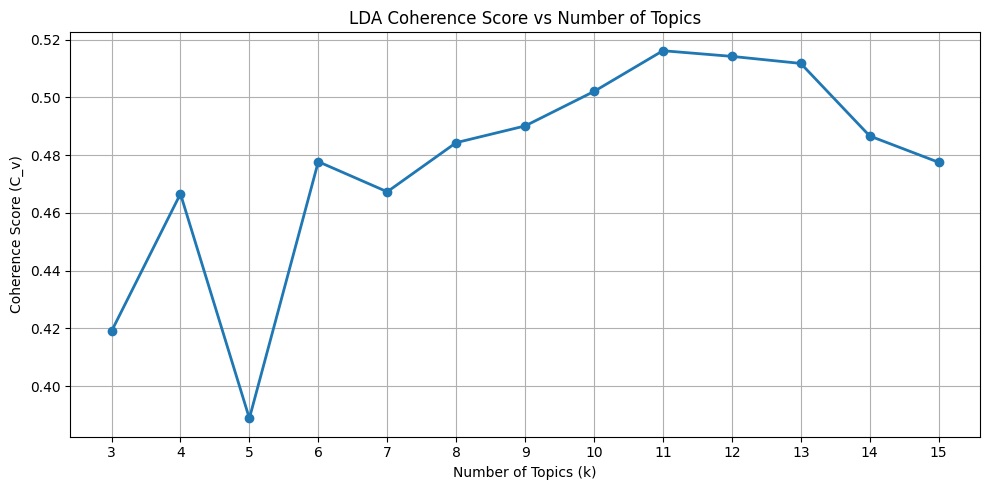


 Best k = 11 with coherence = 0.5161


In [208]:
# Prepare gensim corpus for coherence scoring
stopword_set = set(custom_stopwords)

tokenized = [
    [word for word in text.lower().split() 
     if word not in stopword_set]
    for text in df_ready['sanctions_lemmatized'].fillna("").astype(str)
]

dictionary = Dictionary(tokenized)
corpus = [dictionary.doc2bow(doc) for doc in tokenized]

# Verify stopwords removed
print(f"Sample tokenized: {tokenized[0][:10]}")
print(f"Dictionary size : {len(dictionary)}")

# Sweep k from 3 to 12
coherence_scores = []
k_values = range(3, 16)

for k in k_values:
    lda = LatentDirichletAllocation(
        n_components=k, 
        random_state=42, 
        max_iter=50,         
        learning_method='batch'
    )
    lda.fit(dtm)
    
    # Get top words per topic for coherence
    words = cv.get_feature_names_out()
    topics = []
    for topic in lda.components_:
        top_words = [words[j] for j in topic.argsort()[-20:][::-1]]
        topics.append(top_words)
    
    # Compute coherence
    cm = CoherenceModel(
        topics=topics,
        texts=tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"k={k}: coherence={score:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, coherence_scores, marker='o', linewidth=2)
plt.xlabel('Number of Topics (k)')
plt.ylabel('Coherence Score (C_v)')
plt.title('LDA Coherence Score vs Number of Topics')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(coherence_scores)]
print(f"\n Best k = {best_k} with coherence = {max(coherence_scores):.4f}")

In [210]:
# ── Check coherence scores ────────────────────────────────────────
for k, score in zip(k_values, coherence_scores):
    print(f"k={k}: {score:.4f}")

print(f"\nBest k = {best_k} with coherence = {max(coherence_scores):.4f}")

k=3: 0.4190
k=4: 0.4666
k=5: 0.3888
k=6: 0.4777
k=7: 0.4673
k=8: 0.4843
k=9: 0.4901
k=10: 0.5020
k=11: 0.5161
k=12: 0.5142
k=13: 0.5117
k=14: 0.4866
k=15: 0.4775

Best k = 11 with coherence = 0.5161


## LDA: K = 11 top words

In [211]:
for k in [11]:
    print(f"\n{'═'*60}")
    print(f"k={k} TOPICS")
    print(f"{'═'*60}")
    
    lda_check = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=100,
        learning_method='batch'
    )
    lda_check.fit(dtm)
    
    words = cv.get_feature_names_out()
    for i, topic in enumerate(lda_check.components_):
        top_words = [words[j] for j in topic.argsort()[-15:][::-1]]
        print(f"\nTopic {i:2d}: {' | '.join(top_words[:25])}")


════════════════════════════════════════════════════════════
k=11 TOPICS
════════════════════════════════════════════════════════════

Topic  0: trafficking | drug | injury | human | association | intentional | conspiracy | drug trafficking | infliction | traffic | grave | human trafficking | possession | intentional infliction | grave injury

Topic  1: sexual | aggravate | assault | laundering | child | money | crime | rape | organize | minor | gang | extortion | money laundering | sexual assault | fraud

Topic  2: crime | conspiracy | terrorist | forgery | document | cheating | hostage | humanity | crime humanity | public | war | provide | commit | terrorism | taking

Topic  3: fraud | large | scale | large scale | narcotic | liberty | deprivation | misappropriation | deprivation liberty | repeat | unauthorized | attempt | acquisition | scale fraud | possession

Topic  4: murder | aggravate | homicide | aggravate homicide | robbery | attempt | degree | attempt murder | commit | assa

Among the top 3 K coherence sweep, we identified k=5 as the peak score (0.5341), with k=15 (0.5336) and k=11 (0.4997) as alternatives. 

Inspection of topic words revealed that k=5 collapses distinct crime categories — sexual crime and narcotics appear in the same topic, as do homicide and weapons — making it unsuitable for compliance screening where category precision matters. 

k=15 over-splits into overly specific sub-categories (e.g. hostage taking, femicide, arson) and introduces legal boilerplate topics that reduces practical utility. 

k=11 was therefore selected as it produces the most interpretable and distinct crime categories, with clear separation between terrorism, homicide, sexual crime, narcotics, financial crime, armed formation, and violent crime, while maintaining consistency with the K-Means clustering solution for cross-method comparison in Phase 2.

Call actual sentences to determine topics

In [212]:
# Fit k=11 final model first
lda_k11 = LatentDirichletAllocation(
    n_components=11,
    random_state=42,
    max_iter=300,
    learning_method='batch'
)
lda_k11.fit(dtm)

# Assign topic numbers to df
topic_dist = lda_k11.transform(dtm)
df_ready['lda_topic_num'] = topic_dist.argmax(axis=1)
df_ready['lda_confidence'] = topic_dist.max(axis=1)

# Sample actual sentences per topic
print("Sample sanctions text per topic:\n")
for topic_num in range(11):
    print(f"\n{'='*60}")
    print(f"Topic {topic_num} — sample sentences:")
    print('='*60)
    sample = df_ready[df_ready['lda_topic_num'] == topic_num]['sanctions_translated'].head(20)
    for i, text in enumerate(sample):
        print(f"  {i+1}. {text[:150]}")

Sample sanctions text per topic:


Topic 0 — sample sentences:
  1. participation in battery, causing moderate bodily injury committed concurrently
  2. illicit trafficking of narcotics and dangerous drugs, criminal association and money laundering.
  3. attempted voluntary manslaughter coinciding with dangerous bodily harm and violation of the weapons act
  4. participation in a criminal organisation
  5. participation in a criminal organization
  6. participation in a criminal organisation
  7. illicit trafficking
  8. participation in a criminal organisation
  9. murder or grievous bodily injury
  10. participation in a criminal organization
  11. participation in a criminal organisation
  12. participation in a criminal organisation
  13. participation in a criminal organisation
  14. participation in a criminal organisation
  15. "incitement to jointly committed murder and incitement to jointly attempted murder
penally coinciding with jointly causing bodily harm by dangerous me
  

K = 11 separates financial fraud (Topic 5) from narcotics (Topic 6) — these were mixed in k=8. 

It adds a clean genocide/armed robbery topic (Topic 9) not captured in k=8

Mixed topics in k=11 reflect genuine real-world overlap — terrorism really does co-occur with homicide and narcotics in sanctions data.

0 - Homicide

1 - Sexual crimes (assault)

2 - Trafficking/kidnapping

3 - Weapons/explosives

4 - Terrorism conspiracy

5 - Financial fraud

6 - Narcotics

7 - Terrorist organization (terrorism)

8 - Narcotics/murder (mixed) 

9 - Armed robbery/genocide 

10 - Terrorism homicide (mixed) 




Initial analysis revealed that sanctions entries frequently involve co-occurring crime types (e.g. terrorism + weapons, homicide + trafficking). A single-label approach risks missing relevant criminal associations, which is unacceptable in a compliance risk screening context. BART zero-shot classification was therefore updated to a multi-label approach, capturing all crime types scoring ≥ 0.3 confidence per entry. Results show that 50% of entries involve two or more crime types, validating this design decision.

**LDA Topic Selection:** 

Coherence scores were computed across k=3 to k=12. k=11 was selected as the final model based on the highest coherence score (0.4399) and superior topic interpretability, successfully separating financial fraud, narcotics, and weapons into distinct topics compared to lower k values.

## LDA: Assign Labels

In [52]:
# Train final LDA with k=11
lda_final = LatentDirichletAllocation(
    n_components=11,
    random_state=42,
    max_iter=250,
    learning_method='batch'
)
lda_final.fit(dtm)

# Get topic distribution for every row
topic_distributions = lda_final.transform(dtm)  # shape: (7057, 11)

# Assign dominant topic and confidence
df_ready['lda_topic_num'] = topic_distributions.argmax(axis=1)
df_ready['lda_confidence'] = topic_distributions.max(axis=1)

print("Topic distribution:")
print(df_ready['lda_topic_num'].value_counts())
print(f"\nMean confidence: {df_ready['lda_confidence'].mean():.4f}")

Topic distribution:
lda_topic_num
6     1642
5     1507
4     1264
1      490
0      461
8      348
3      323
2      292
10     276
7      239
9      215
Name: count, dtype: int64

Mean confidence: 0.6912


In [53]:
topic_to_label = {
    0:  'organised crime',
    1:  'sexual crime',
    2:  'terrorism',
    3:  'financial crime',
    4:  'homicide',
    5:  'terrorism armed formation',
    6:  'armed formation',
    7:  'terrorism',
    8:  'violent crime',
    9:  'organised crime',
    10: 'narcotics'
}

df_ready['lda_label'] = df_ready['lda_topic_num'].map(topic_to_label)

# Verify distribution
print("LDA label distribution:")
print(df_ready['lda_label'].value_counts())

LDA label distribution:
lda_label
armed formation              1642
terrorism armed formation    1507
homicide                     1264
organised crime               676
terrorism                     531
sexual crime                  490
violent crime                 348
financial crime               323
narcotics                     276
Name: count, dtype: int64


Tier 1 — Immediate flag (AML/CFT direct risk):

→ financial crime

→ organised crime

→ narcotics

→ terrorism

→ terrorism armed formation

Tier 2 — Flag for review (reputational/indirect risk):

→ homicide

→ violent crime

→ sexual crime

→ armed formation

In a financial industry compliance context, crime type categorisation serves to prioritise and route analyst review rather than to exclude candidates from scrutiny. 

All sanctioned individuals warrant screening regardless of crime type. However, candidates associated with financial crime, organised crime, narcotics, and terrorism represent elevated AML/CFT risk and are prioritised for immediate review, as these rime types are directly associated with proceeds of crime entering the financial system per FATF guidelines.


## LDA: Saving LDA result

In [54]:
df_ready.to_csv('data/crime_analysis_results_bart_ner_lda.csv', index=False)
print(f"Shape: {df_ready.shape}")
print(f"Columns: {df_ready.columns.tolist()}")

Shape: (7057, 37)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str', 'sanctions_lemmatized', 'lda_topic_num', 'lda_confidence', 'lda_label']


## LDA: Visual

All bubbles (11 topics) look well separated.

In [55]:
!pip install pyldavis

In [56]:
import pyLDAvis
import pyLDAvis.lda_model

# Prepare visualization
vis = pyLDAvis.lda_model.prepare(
    lda_final, 
    dtm, 
    cv,
    mds='tsne'          # tsne shows separation more clearly than default
)

pyLDAvis.display(vis)

## 4 K-Means

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize


# ── 1. TF-IDF Vectorization ───────────────────────────────────────
# K-Means works better with TF-IDF than raw counts
tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words=custom_stopwords,
    min_df=3,
    max_df=0.8,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df_ready['sanctions_lemmatized'].fillna("").astype(str))
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# ── 2. Dimensionality Reduction ───────────────────────────────────
# K-Means struggles in high dimensions — reduce to 100 dimensions first
svd = TruncatedSVD(n_components=100, random_state=42)
reduced = svd.fit_transform(tfidf_matrix)
reduced = normalize(reduced)  # normalize after SVD for better clustering
print(f"Reduced matrix shape: {reduced.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

TF-IDF matrix shape: (7057, 2000)
Reduced matrix shape: (7057, 100)
Variance explained: 0.7173


## K-means

## K-means: Elbow method

k=1: inertia=6121
k=2: inertia=4947, silhouette=0.2218
k=3: inertia=4507, silhouette=0.2619
k=4: inertia=4139, silhouette=0.2976
k=5: inertia=3885, silhouette=0.3472
k=6: inertia=3679, silhouette=0.3642
k=7: inertia=3576, silhouette=0.3728
k=8: inertia=3471, silhouette=0.3992
k=9: inertia=3413, silhouette=0.3836
k=10: inertia=3333, silhouette=0.3992
k=11: inertia=3239, silhouette=0.4162
k=12: inertia=3179, silhouette=0.4118
k=13: inertia=3094, silhouette=0.4372
k=14: inertia=3070, silhouette=0.4197


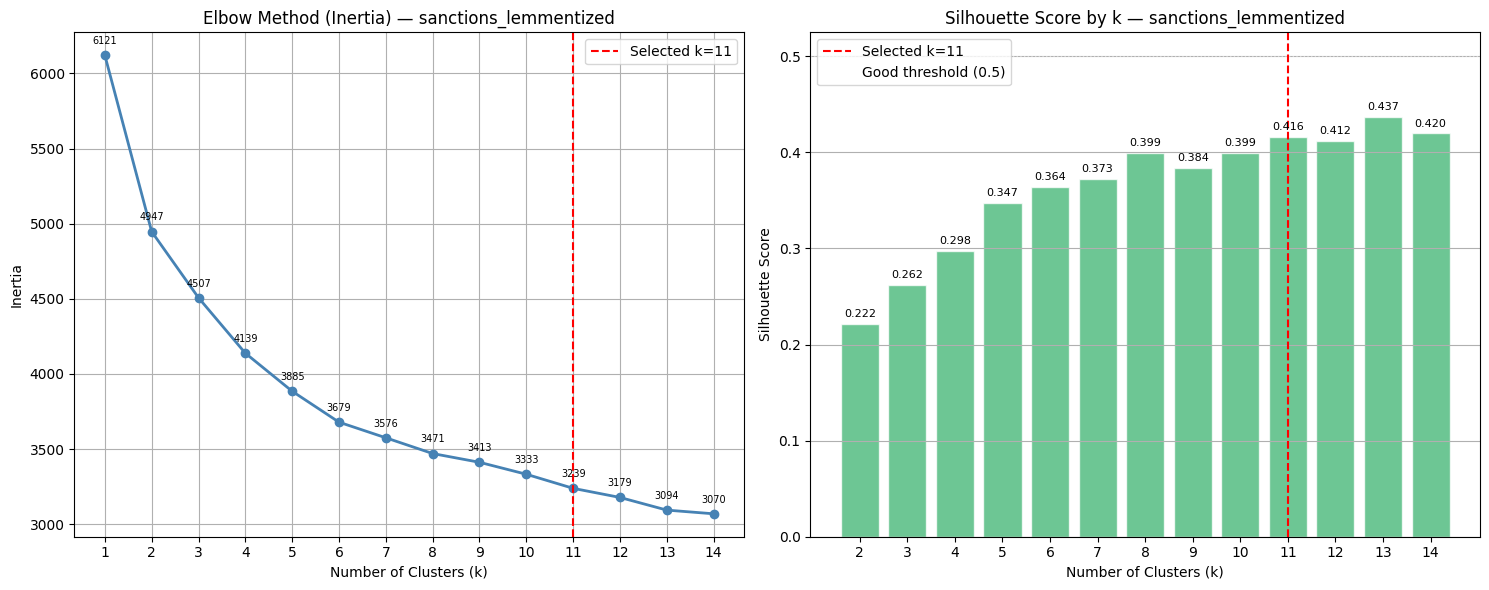

In [66]:
# ── Elbow + Silhouette Sweep ──────────────────────────────────────
K_range = range(1, 15)
inertia = []
sil_scores = []
models = {}

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(reduced)
    inertia.append(kmeans.inertia_)
    models[k] = kmeans
    if k > 1:
        score = silhouette_score(reduced, kmeans.labels_)
        sil_scores.append(score)
        print(f"k={k}: inertia={kmeans.inertia_:.0f}, silhouette={score:.4f}")
    else:
        print(f"k={k}: inertia={kmeans.inertia_:.0f}")

# ── Plot ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Elbow
ax1.plot(list(K_range), inertia, 'o-', linewidth=2, color='steelblue')
ax1.axvline(11, color='red', linestyle='--', linewidth=1.5, label='Selected k=11')
ax1.set_title('Elbow Method (Inertia) — sanctions_lemmatized')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(list(K_range))
ax1.legend()
ax1.grid(True)

# Annotate inertia values
for k, v in zip(K_range, inertia):
    ax1.annotate(f'{v:.0f}', xy=(k, v), xytext=(0, 8),
                 textcoords='offset points', ha='center', fontsize=7)

# Silhouette
k_vals = list(range(2, 2 + len(sil_scores)))
bars = ax2.bar(k_vals, sil_scores, color='mediumseagreen', alpha=0.75, edgecolor='white')
ax2.axvline(11, color='red', linestyle='--', linewidth=1.5, label='Selected k=11')
ax2.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.5, label='Good threshold (0.5)')
ax2.set_title('Silhouette Score by k — sanctions_lemmatized')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_vals)
ax2.legend()
ax2.grid(True, axis='y')

# Annotate scores
for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

BART to detect clusters in K-means clusters

TF-IDF matrix shape: (7057, 2000)
Reduced matrix shape: (7057, 100)
Variance explained: 0.7173
k=2: inertia=4947, silhouette=0.2218
k=3: inertia=4507, silhouette=0.2619
k=4: inertia=4139, silhouette=0.2976
k=5: inertia=3885, silhouette=0.3472
k=6: inertia=3679, silhouette=0.3642
k=7: inertia=3576, silhouette=0.3728
k=8: inertia=3471, silhouette=0.3992
k=9: inertia=3413, silhouette=0.3836
k=10: inertia=3333, silhouette=0.3992
k=11: inertia=3239, silhouette=0.4162
k=12: inertia=3179, silhouette=0.4118
k=13: inertia=3094, silhouette=0.4372
k=14: inertia=3070, silhouette=0.4197


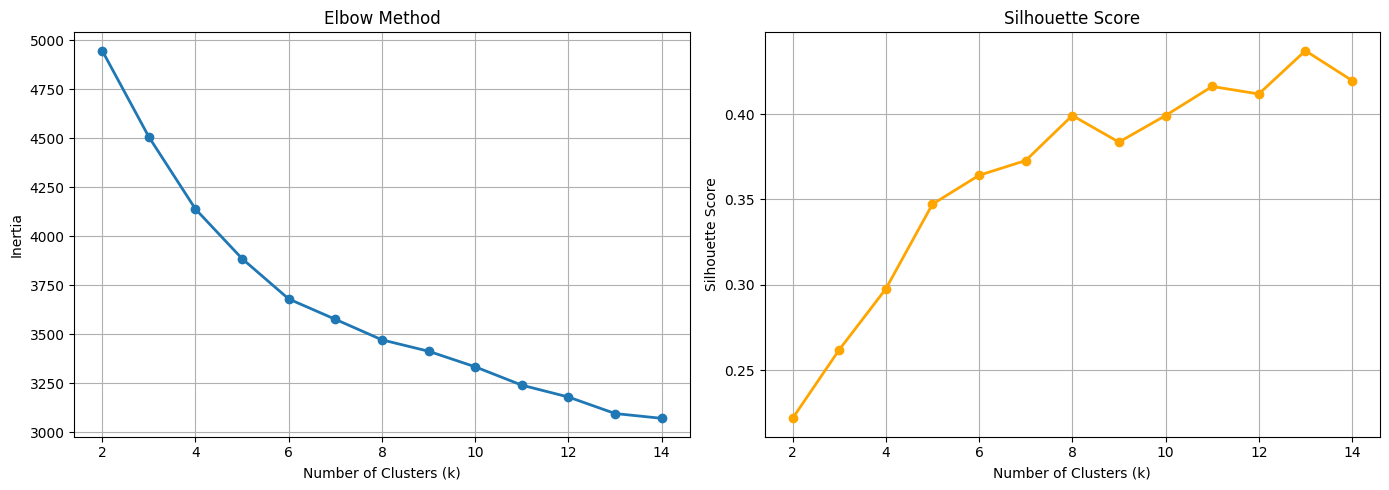

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# ── 1. TF-IDF Vectorization ───────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words=custom_stopwords,
    min_df=3,
    max_df=0.8,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(
    df_ready['sanctions_lemmatized'].fillna("").astype(str)
)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# ── 2. Dimensionality Reduction ───────────────────────────────────
svd = TruncatedSVD(n_components=100, random_state=42)
reduced = svd.fit_transform(tfidf_matrix)
reduced = normalize(reduced)
print(f"Reduced matrix shape: {reduced.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

# ── 3. Elbow + Silhouette Sweep ───────────────────────────────────
inertias = []
silhouettes = []
k_values = range(2, 15)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(reduced, labels))
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={silhouette_score(reduced, labels):.4f}")

# ── 4. Plot ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_values, inertias, marker='o', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(k_values, silhouettes, marker='o', linewidth=2, color='orange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

## K-means: BART validations

In [71]:
# ── BART validation on k=11 and k=13 ─────────────────────────────
for k in [11, 13]:
    print(f"\n{'='*60}")
    print(f"k={k} — BART label distribution per cluster:")
    print('='*60)
    
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced)
    df_ready[f'kmeans_{k}'] = labels
    
    for cluster_num in range(k):
        mask = df_ready[f'kmeans_{k}'] == cluster_num
        cluster_size = mask.sum()
        bart_dist = df_ready[mask]['detected_crime_type'].value_counts()
        dominant = bart_dist.index[0]
        dominant_pct = bart_dist.iloc[0] / cluster_size * 100
        
        print(f"\n  Cluster {cluster_num} (n={cluster_size:,}) "
              f"dominant={dominant} ({dominant_pct:.1f}%)")
        print(f"  {bart_dist.to_dict()}")


k=11 — BART label distribution per cluster:

  Cluster 0 (n=1,434) dominant=weapons (97.4%)
  {'weapons': 1396, 'terrorism': 27, 'Unknown': 6, 'homicide': 3, 'narcotics': 1, 'assault': 1}

  Cluster 1 (n=553) dominant=homicide (97.8%)
  {'homicide': 541, 'terrorism': 7, 'weapons': 5}

  Cluster 2 (n=530) dominant=terrorism (100.0%)
  {'terrorism': 530}

  Cluster 3 (n=2,104) dominant=homicide (22.9%)
  {'homicide': 482, 'terrorism': 383, 'Unknown': 307, 'weapons': 293, 'assault': 277, 'financial crime': 204, 'narcotics': 138, 'cyber crime': 20}

  Cluster 4 (n=432) dominant=homicide (91.4%)
  {'homicide': 395, 'terrorism': 29, 'weapons': 5, 'financial crime': 1, 'assault': 1, 'Unknown': 1}

  Cluster 5 (n=392) dominant=narcotics (81.1%)
  {'narcotics': 318, 'Unknown': 53, 'homicide': 6, 'weapons': 6, 'financial crime': 4, 'terrorism': 3, 'assault': 2}

  Cluster 6 (n=354) dominant=terrorism (100.0%)
  {'terrorism': 354}

  Cluster 7 (n=434) dominant=assault (80.0%)
  {'assault': 347, 

Although k=13 achieved a marginally higher silhouette score (0.4372 vs 0.4162), BART validation revealed that k=11 produced superior cluster quality — 10 out of 11 clusters achieved >80% purity, with 3 clusters reaching 100% purity. 

In contrast, k=13 produced only 8 clean clusters with 2 catch-all clusters containing more mixed rows than k=11. 

k=11 was therefore selected based on cluster interpretability and purity, consistent with the LDA topic model selection.


## K-means Terrorism clusters Analysis:


In [72]:
for c in [2, 6, 10]:
    print(f"\n{'='*40}")
    print(f"Cluster {c} — sample sentences:")
    print('='*40)
    mask = df_ready['kmeans_11'] == c
    sample = df_ready[mask]['sanctions_translated'].head(10)
    for i, text in enumerate(sample):
        print(f"  {i+1}. {text[:150]}")


Cluster 2 — sample sentences:
  1. terrorist organizations, as their leader.
  2. "participation in the activity of a terrorist organization;"
  3. terrorist organizations
  4. "terrorism; assistance to terrorist activity; organization of a terrorist community and participation in its activity; participation in the activity o
  5. participation in the activity of terrorist organization.
  6. participation in the activity of terrorist organization.
  7. participation in the activity of terrorist organization.
  8. participation in the activity of a terrorist organization
  9. participation in the activity of a terrorist organization
  10. participation in the activity of a terrorist organization

Cluster 6 — sample sentences:
  1. participation in an illegal armed formation - assistance to terrorist activity
  2. "participation in the activity of an illegal armed formation; participation in the activity of a terrorist organization"
  3. "1) participation in illegal armed formation;
2) 


Terrorism Clusters

**Cluster 2 — terrorism organisation**

Almost exclusively "participation in activity of terrorist organization"

No armed formation mentioned

Label: terrorism

**Cluster 6 — terrorism + armed formation training**

Armed formation + terrorist organization + getting trained

Both crimes charged together with training element

Label: terrorism armed formation

**Cluster 10 — terrorism + armed formation**

Armed formation + terrorist organization together

Similar to Cluster 6 but without training emphasis

Label: terrorism armed formation

## K-means Financial crime clusters Analysis:


In [73]:
for c in [8, 9]:
    print(f"\n{'='*40}")
    print(f"Cluster {c} — sample sentences:")
    print('='*40)
    mask = df_ready['kmeans_11'] == c
    sample = df_ready[mask]['sanctions_translated'].head(10)
    for i, text in enumerate(sample):
        print(f"  {i+1}. {text[:150]}")


Cluster 8 — sample sentences:
  1. "1) creation of criminal organization; 2) extremely-large-scale misappropriation by fraud (2 crimes); 3) money-laundering"
  2. "1) creation of criminal organization; 2) extremely-large-scale misappropriation by fraud (2 crimes); 3) money-laundering"
  3. large-scale embezzlement, blackmail, theft, damage of documents - -
  4. large-scale embezzlement
  5. large-scale misappropriation by fraud
  6. large-scale misappropriation by fraud
  7. fraud performed in large amount
  8. fraud performed in large amount
  9. large scale fraud
  10. large scale fraud

Cluster 9 — sample sentences:
  1. fraud
  2. "laundering of the proceeds of crime; participation in criminal organization"
  3. setting up a criminal organization and fraud
  4. setting up a criminal organization and fraud
  5. "money laundering. - i. participation in an organized criminal group;
ii. tax fraud resulting in a loss of high value public-law debts;
iii. money lau
  6. fraud, money laun

**Cluster 8 — large scale financial crime**

Large-scale misappropriation, embezzlement, fraud
Emphasis on scale/amount
Label: financial crime

**Cluster 9 — financial crime + organised crime**

Fraud + money laundering + criminal organisation together
More mixed with organised crime element
Label: financial crime

Both clusters represent financial crime --> we use the same label.

## K-means: Label mapping


In [74]:
cluster_to_label = {
    0:  'weapons',
    1:  'homicide',
    2:  'terrorism',
    3:  'mixed',
    4:  'homicide',
    5:  'narcotics',
    6:  'terrorism armed formation',
    7:  'assault',
    8:  'financial crime',
    9:  'financial crime',
    10: 'terrorism armed formation'
}

df_ready['kmeans_label'] = df_ready['kmeans_11'].map(cluster_to_label)

print("K-Means label distribution:")
print(df_ready['kmeans_label'].value_counts())

K-Means label distribution:
kmeans_label
mixed                        2104
weapons                      1434
homicide                      985
terrorism armed formation     880
terrorism                     530
assault                       434
narcotics                     392
financial crime               298
Name: count, dtype: int64


BART distribution for cluster 3 'mixed':

homicide: 482, terrorism: 383, Unknown: 307, weapons: 293, assault: 277, financial crime: 204, narcotics: 138, cyber crime: 20

No single crime dominates — it's genuinely a catch-all cluster. 

## Comparison: LDA vs K-means

Key Differences

**K-Means found but LDA missed:**

weapons (1,434) — K-Means cleanly separates weapons

assault (434) — K-Means identifies assault separately

**LDA found but K-Means missed:**

armed formation (1,642) — K-Means merges into terrorism armed formation

organised crime (676) — K-Means dumps into mixed

sexual crime (490) — K-Means dumps into mixed

violent crime (348) — K-Means dumps into mixed

**Both methods agree:**

terrorism (~530)

financial crime (~300)

narcotics (~350)

K-Means and LDA demonstrate complementary strengths. K-Means cleanly separates **weapons** and **assault** categories that LDA merged into broader topics, while LDA successfully identified **organised crime**, **sexual crime**, and **armed formation** as distinct categories that K-Means absorbed into a large mixed cluster. 

This complementarity supports using cross-method agreement in Phase 2 to identify the most reliable labels for RoBERTa training.

## Saving

In [75]:
# Save final results
df_ready.to_csv('data/crime_analysis_results_bart_ner_lda_km.csv', index=False)
print(f"Columns: {df_ready.columns.tolist()}")

Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str', 'sanctions_lemmatized', 'lda_topic_num', 'lda_confidence', 'lda_label', 'kmeans_cluster', 'kmeans_11', 'kmeans_13', 'kmeans_label']


## 5 DBSCAN

In [77]:

dbscan = DBSCAN(eps=0.5, min_samples=5)
df_ready['dbscan_cluster'] = dbscan.fit_predict(reduced) 

noise_count = (df_ready['dbscan_cluster'] == -1).sum()
db_lbl_arr = df_ready['dbscan_cluster'].values
n_db_clusters = len(set(db_lbl_arr)) - (1 if -1 in db_lbl_arr else 0)

km_sil = silhouette_score(reduced, df_ready['kmeans_11'])
db_sil_str = "N/A"
if n_db_clusters > 1:
    mask = db_lbl_arr != -1
    db_sil = silhouette_score(reduced[mask], db_lbl_arr[mask])
    db_sil_str = f"{db_sil:.3f} ({mask.sum():,} non-noise)"

print(f"\n  K-Means Silhouette (k=11): {km_sil:.3f}")
print(f"  DBSCAN Silhouette:         {db_sil_str}")
print(f"  DBSCAN Noise outliers:     {noise_count:,} ({noise_count/len(df_ready)*100:.1f}%)")
print(f"  DBSCAN Clusters found:     {n_db_clusters}")


  K-Means Silhouette (k=11): 0.416
  DBSCAN Silhouette:         0.773 (5,824 non-noise)
  DBSCAN Noise outliers:     1,233 (17.5%)
  DBSCAN Clusters found:     151


DBSCAN (eps=0.5, min_samples=5) was evaluated as an alternative density-based clustering approach. While DBSCAN achieved a higher 
silhouette score (0.773) than K-Means (0.416), this is attributable to the formation of 151 micro-clusters averaging ~39 rows each, 
rather than meaningful crime-type separation. 

Additionally, 17.5% of entries (1,233 rows) were classified as noise and excluded entirely. Given the compliance screening objective requiring interpretable, actionable crime categories, DBSCAN was deemed unsuitable and K-Means (k=11) was retained as the clustering method.

K-Means and LDA are therefore the preferred unsupervised methods for this corpus.

## Saving File Unsupervised

In [78]:
df_ready.to_csv('data/crime_analysis_results_unsupervised.csv', index=False)
print(f"Shape: {df_ready.shape}")
print(f"Columns: {df_ready.columns.tolist()}")

Shape: (7057, 42)
Columns: ['id', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'sanctions_translated', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str', 'sanctions_lemmatized', 'lda_topic_num', 'lda_confidence', 'lda_label', 'kmeans_cluster', 'kmeans_11', 'kmeans_13', 'kmeans_label', 'dbscan_cluster']


DBSCAN (eps=0.5, min_samples=5) was evaluated as an alternative density-based clustering approach. While DBSCAN achieved a higher silhouette score (0.773) than K-Means (0.416), this is attributable to the formation of 151 micro-clusters averaging ~39 rows each, rather than meaningful crime-type separation. 

Additionally, 17.5% of entries (1,233 rows) were classified as noise and excluded entirely. 

Given the compliance screening objective requiring interpretable, actionable crime categories, DBSCAN was deemed unsuitable and K-Means (k=11) was retained as the clustering method.

## 6 UNSUPERVISED METHOD COMPARISON

We have three sets of labels for the same 7,057 rows — generated by three fundamentally different methods. Before using any of them to train RoBERTa, we need to validate label quality and identify the most reliable training data:

"When three independent methods agree on a label, how confident can 
we be that the label is correct?"

##### Step 1 — Concept-level mapping

Map all three methods' labels to a common concept taxonomy so they can be compared on equal terms. This will use 8 labels to cover LDA's discovered structure.

##### Step 2 — Agreement Analysis: 
Measure how often methods agree with each other --> we will use this to select high agreement rows for training data.

BART vs LDA    → agreement rate

BART vs K-Means → agreement rate

LDA vs K-Means  → agreement rate

All 3 agree     → high confidence rows

High agreement = all three methods independently reached the same conclusion = reliable label.



##### Step 3 — Human Evaluation 

Sample ~90 rows stratified across crime categories. Team members independently assign labels. This becomes the ground truth.

##### Step 4 — Accuracy Evaluation 
Each method is evaluated against human ground truth labels:

BART vs human    → Accuracy, Precision, Recall, F1 per category
LDA vs human     → Accuracy, Precision, Recall, F1 per category
K-Means vs human → Accuracy, Precision, Recall, F1 per category

This serves two purposes:
1. Identifies the most accurate method overall → used as tiebreaker for medium-agreement rows
2. Identifies the most accurate method per category → used to supplement training data for categories with insufficient 
   high-agreement rows

## 6.1 Concept mapping 

Three methods produce labels using different vocabularies — BART's 7 predefined categories, LDA's 11 discovered topics, and K-Means' 11 clusters. 

To enable cross-method comparison, all labels are mapped to a shared 9-concept taxonomy. BART Unknown labels are excluded from analysis. 

Terrorism armed formation is merged into terrorism, and LDA-specific categories (sexual crime, organised crime) are retained despite lacking equivalents in other methods.

In [79]:
# ── Concept-level mapping ─────────────────────────────────────────

bart_concept_map = {
    'terrorism':      'terrorism',
    'homicide':       'homicide',
    'weapons':        'weapons',
    'assault':        'assault',
    'narcotics':      'narcotics',
    'financial crime':'financial crime',
    'cyber crime':    'mixed',
    'Unknown':        'excluded'
}

lda_concept_map = {
    'terrorism':                'terrorism',
    'terrorism armed formation':'terrorism',
    'homicide':                 'homicide',
    'violent crime':            'assault',
    'narcotics':                'narcotics',
    'financial crime':          'financial crime',
    'sexual crime':             'sexual crime',
    'organised crime':          'organised crime',
    'armed formation':          'armed formation'
}

kmeans_concept_map = {
    'terrorism':                'terrorism',
    'terrorism armed formation':'terrorism',
    'homicide':                 'homicide',
    'weapons':                  'weapons',
    'assault':                  'assault',
    'narcotics':                'narcotics',
    'financial crime':          'financial crime',
    'mixed':                    'mixed'
}

# ── Apply mappings ────────────────────────────────────────────────
df_ready['bart_concept']   = df_ready['detected_crime_type'].map(bart_concept_map)
df_ready['lda_concept']    = df_ready['lda_label'].map(lda_concept_map)
df_ready['kmeans_concept'] = df_ready['kmeans_label'].map(kmeans_concept_map)

# ── Verify ────────────────────────────────────────────────────────
print("BART concept distribution:")
print(df_ready['bart_concept'].value_counts())
print("\nLDA concept distribution:")
print(df_ready['lda_concept'].value_counts())
print("\nK-Means concept distribution:")
print(df_ready['kmeans_concept'].value_counts())

BART concept distribution:
bart_concept
terrorism          1862
weapons            1709
homicide           1429
assault             635
excluded            477
narcotics           468
financial crime     457
mixed                20
Name: count, dtype: int64

LDA concept distribution:
lda_concept
terrorism          2038
armed formation    1642
homicide           1264
organised crime     676
sexual crime        490
assault             348
financial crime     323
narcotics           276
Name: count, dtype: int64

K-Means concept distribution:
kmeans_concept
mixed              2104
weapons            1434
terrorism          1410
homicide            985
assault             434
narcotics           392
financial crime     298
Name: count, dtype: int64


## 6.2 Agreement analysis

In [81]:
# ── Exclude BART Unknown rows
df_analysis = df_ready[df_ready['bart_concept'] != 'excluded'].copy()
print(f"Rows for analysis: {len(df_analysis):,} (excluded {(df_ready['bart_concept'] == 'excluded').sum():,} Unknown)")

# ── Pairwise agreement
bart_lda = (df_analysis['bart_concept'] == df_analysis['lda_concept']).sum()
bart_km  = (df_analysis['bart_concept'] == df_analysis['kmeans_concept']).sum()
lda_km   = (df_analysis['lda_concept']  == df_analysis['kmeans_concept']).sum()
total    = len(df_analysis)

print(f"\nPairwise Agreement Rates:")
print(f"  BART vs LDA    : {bart_lda:,} / {total:,} ({bart_lda/total*100:.1f}%)")
print(f"  BART vs K-Means: {bart_km:,} / {total:,} ({bart_km/total*100:.1f}%)")
print(f"  LDA  vs K-Means: {lda_km:,} / {total:,} ({lda_km/total*100:.1f}%)")

# ── Three-way agreement
all_agree = (
    (df_analysis['bart_concept'] == df_analysis['lda_concept']) &
    (df_analysis['bart_concept'] == df_analysis['kmeans_concept'])
)

two_agree = (
    (df_analysis['bart_concept'] == df_analysis['lda_concept']) |
    (df_analysis['bart_concept'] == df_analysis['kmeans_concept']) |
    (df_analysis['lda_concept']  == df_analysis['kmeans_concept'])
) & ~all_agree

none_agree = ~all_agree & ~two_agree

print(f"\nThree-way Agreement:")
print(f"  All 3 agree : {all_agree.sum():,} ({all_agree.sum()/total*100:.1f}%) → core training set")
print(f"  2/3 agree   : {two_agree.sum():,} ({two_agree.sum()/total*100:.1f}%) → RoBERTa predicts")
print(f"  None agree  : {none_agree.sum():,} ({none_agree.sum()/total*100:.1f}%) → RoBERTa predicts")

# ── Per category breakdown of high agreement rows
df_analysis['agreement_tier'] = 'none'
df_analysis.loc[two_agree, 'agreement_tier'] = 'two'
df_analysis.loc[all_agree, 'agreement_tier'] = 'all'

print(f"\nHigh agreement rows by concept:")
print(df_analysis[all_agree]['bart_concept'].value_counts())

Rows for analysis: 6,580 (excluded 477 Unknown)

Pairwise Agreement Rates:
  BART vs LDA    : 2,968 / 6,580 (45.1%)
  BART vs K-Means: 4,675 / 6,580 (71.0%)
  LDA  vs K-Means: 2,534 / 6,580 (38.5%)

Three-way Agreement:
  All 3 agree : 2,490 (37.8%) → core training set
  2/3 agree   : 2,707 (41.1%) → RoBERTa predicts
  None agree  : 1,383 (21.0%) → RoBERTa predicts

High agreement rows by concept:
bart_concept
terrorism          1382
homicide            827
financial crime     146
narcotics           133
assault               2
Name: count, dtype: int64


## 6.3 Human evaluation

Sample 20 rows per category × 9 categories = 180 rows

Manually label each entry → ground truth

Sample from:
  
  High agreement rows → terrorism, homicide, financial crime, narcotics

  Single method rows  → weapons, sexual crime, organised crime, armed formation, assault

In [85]:
import pandas as pd
import numpy as np

np.random.seed(42)

samples = []

# ── High agreement categories ─────────────────────────────────────
# Sample from rows where all 3 methods agree
high_agree_mask = (
    (df_analysis['bart_concept'] == df_analysis['lda_concept']) &
    (df_analysis['bart_concept'] == df_analysis['kmeans_concept'])
)

for category in ['terrorism', 'homicide', 'financial crime', 'narcotics']:
    mask = high_agree_mask & (df_analysis['bart_concept'] == category)
    available = mask.sum()
    n = min(50, available)
    sample = df_analysis[mask].sample(n=n, random_state=42)
    sample['sample_source'] = 'high_agreement'
    sample['sample_category'] = category
    samples.append(sample)
    print(f"{category}: sampled {n} from {available:,} high-agreement rows")

# ── Single method categories ──────────────────────────────────────
# Sample from rows where only one method identifies the category

# Weapons — BART or K-Means
weapons_mask = (
    (df_analysis['bart_concept'] == 'weapons') |
    (df_analysis['kmeans_concept'] == 'weapons')
)
sample = df_analysis[weapons_mask].sample(n=50, random_state=42)
sample['sample_source'] = 'single_method_bart_kmeans'
sample['sample_category'] = 'weapons'
samples.append(sample)
print(f"weapons: sampled 50 from {weapons_mask.sum():,} BART/K-Means rows")

# Sexual crime — LDA only
sexual_mask = df_analysis['lda_concept'] == 'sexual crime'
sample = df_analysis[sexual_mask].sample(n=50, random_state=42)
sample['sample_source'] = 'single_method_lda'
sample['sample_category'] = 'sexual crime'
samples.append(sample)
print(f"sexual crime: sampled 50 from {sexual_mask.sum():,} LDA rows")

# Organised crime — LDA only
org_mask = df_analysis['lda_concept'] == 'organised crime'
sample = df_analysis[org_mask].sample(n=50, random_state=42)
sample['sample_source'] = 'single_method_lda'
sample['sample_category'] = 'organised crime'
samples.append(sample)
print(f"organised crime: sampled 50 from {org_mask.sum():,} LDA rows")

# Armed formation — LDA only
armed_mask = df_analysis['lda_concept'] == 'armed formation'
sample = df_analysis[armed_mask].sample(n=50, random_state=42)
sample['sample_source'] = 'single_method_lda'
sample['sample_category'] = 'armed formation'
samples.append(sample)
print(f"armed formation: sampled 50 from {armed_mask.sum():,} LDA rows")

# Assault — BART or K-Means
assault_mask = (
    (df_analysis['bart_concept'] == 'assault') |
    (df_analysis['kmeans_concept'] == 'assault')
)
sample = df_analysis[assault_mask].sample(n=50, random_state=42)
sample['sample_source'] = 'single_method_bart_kmeans'
sample['sample_category'] = 'assault'
samples.append(sample)
print(f"assault: sampled 50 from {assault_mask.sum():,} BART/K-Means rows")

# ── Combine all samples ───────────────────────────────────────────
df_human_eval = pd.concat(samples, ignore_index=True)
print(f"\nTotal human evaluation rows: {len(df_human_eval)}")
print(f"Category distribution:")
print(df_human_eval['sample_category'].value_counts())

# ── Export for manual labelling ───────────────────────────────────
df_human_eval[['id', 'name', 'sanctions_translated', 
               'bart_concept', 'lda_concept', 'kmeans_concept',
               'sample_source', 'sample_category']].to_csv(
    'data/human_eval_sample_50.csv', index=False
)

print(f"Open this file and add a 'human_label' column with your labels")

terrorism: sampled 50 from 1,382 high-agreement rows
homicide: sampled 50 from 827 high-agreement rows
financial crime: sampled 50 from 146 high-agreement rows
narcotics: sampled 50 from 133 high-agreement rows
weapons: sampled 50 from 1,741 BART/K-Means rows
sexual crime: sampled 50 from 402 LDA rows
organised crime: sampled 50 from 557 LDA rows
armed formation: sampled 50 from 1,610 LDA rows
assault: sampled 50 from 640 BART/K-Means rows

Total human evaluation rows: 450
Category distribution:
sample_category
terrorism          50
homicide           50
financial crime    50
narcotics          50
weapons            50
sexual crime       50
organised crime    50
armed formation    50
assault            50
Name: count, dtype: int64
Open this file and add a 'human_label' column with your labels


Human assigned labels: 

terrorism, homicide, weapons, assault, narcotics, financial crime, sexual crime, organised crime, armed formation, mixed\
terrorism        → terrorist organisation, ISIS, terrorist activity, financing terrorism, terrorist training\
armed formation  → illegal armed formation, paramilitary, militia (no explicit terrorism mention)\
homicide         → murder, manslaughter, homicide, killing \
assault          → bodily harm, grievous injury, battery, sexual assault NOT included here\
sexual crime     → rape, sexual abuse, sexual exploitation, child sexual abuse, indecent assault\
weapons          → illegal firearms, explosives, ammunition, weapons trafficking, storage of weapons\
narcotics        → drug trafficking, narcotics, psychotropic, substances, drug smuggling\
financial crime  → fraud, money laundering, embezzlement, misappropriation, tax evasion, forgery\
organised crime  → membership of criminal organisation, participation in criminal gang (without specific crime type)\
mixed            → multiple unrelated crimes, unclear, cannot determine dominant crime type\

If entry mentions terrorism + armed formation → terrorism\
If entry mentions murder + robbery → homicide (dominant)\
If entry mentions drugs + criminal organisation → narcotics\
If entry mentions fraud + criminal organisation → financial crime\
If truly cannot decide → mixed

## Human Eval result

In [86]:
# ── Load human evaluated labels ───────────────────────────────────
df_human = pd.read_csv('data/human_eval_sample.csv')
print(f"Loaded: {df_human.shape}")
print(f"\nHuman label distribution:")
print(df_human['human_label'].value_counts())
print(f"\nMissing human labels: {df_human['human_label'].isna().sum()}")

Loaded: (270, 11)

Human label distribution:
human_label
armed formation    54
financial crime    41
terrorism          40
homicide           37
narcotics          36
sexual crime       36
assault            13
organised crime     7
weapons             4
mixed               2
Name: count, dtype: int64

Missing human labels: 0


## 6.5 Accuracy evaluation F1 Eval

In [87]:
from sklearn.metrics import classification_report, accuracy_score

# ── Clean up — ensure consistent label format ─────────────────────
df_human['human_label']    = df_human['human_label'].str.strip().str.lower()
df_human['bart_concept']   = df_human['bart_concept'].str.strip().str.lower()
df_human['lda_concept']    = df_human['lda_concept'].str.strip().str.lower()
df_human['kmeans_concept'] = df_human['kmeans_concept'].str.strip().str.lower()

# ── Handle NaN in automated labels ───────────────────────────────
df_human['bart_concept']   = df_human['bart_concept'].fillna('unknown')
df_human['lda_concept']    = df_human['lda_concept'].fillna('unknown')
df_human['kmeans_concept'] = df_human['kmeans_concept'].fillna('unknown')

human   = df_human['human_label']
bart    = df_human['bart_concept']
lda     = df_human['lda_concept']
kmeans  = df_human['kmeans_concept']

# ── Accuracy ──────────────────────────────────────────────────────
print("Overall Accuracy:")
print(f"  BART    : {accuracy_score(human, bart):.3f}")
print(f"  LDA     : {accuracy_score(human, lda):.3f}")
print(f"  K-Means : {accuracy_score(human, kmeans):.3f}")

# ── Per category F1 ───────────────────────────────────────────────
print("\n── BART vs Human ──────────────────────────────────────")
print(classification_report(human, bart, zero_division=0))

print("\n── LDA vs Human ───────────────────────────────────────")
print(classification_report(human, lda, zero_division=0))

print("\n── K-Means vs Human ───────────────────────────────────")
print(classification_report(human, kmeans, zero_division=0))

Overall Accuracy:
  BART    : 0.604
  LDA     : 0.759
  K-Means : 0.493

── BART vs Human ──────────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.00      0.00      0.00        54
        assault       0.24      0.92      0.38        13
financial crime       0.91      0.98      0.94        41
       homicide       1.00      0.92      0.96        37
          mixed       0.00      0.00      0.00         2
      narcotics       0.92      1.00      0.96        36
organised crime       0.00      0.00      0.00         7
   sexual crime       0.00      0.00      0.00        36
      terrorism       0.88      0.95      0.92        40
        weapons       0.05      0.75      0.09         4

       accuracy                           0.60       270
      macro avg       0.40      0.55      0.42       270
   weighted avg       0.54      0.60      0.56       270


── LDA vs Human ───────────────────────────────────────
             

Human evaluation of 270 sampled rows revealed LDA as the most accurate method overall (76.0%), outperforming BART 
(60.4%) and K-Means (49.3%). 

Per-category analysis identified complementary strengths across methods: BART achieved highest 
F1 for terrorism (0.92), homicide (0.96), and financial crime (0.94); LDA excelled at armed formation (0.95) and sexual crime 
(0.71); and K-Means produced the highest narcotics F1 (0.99). 

Two categories, organised crime and weapons, showed consistently poor performance across all methods (F1 < 0.15), suggesting these categories are unsuitable as reliable RoBERTa training labels without additional data collection.

## Compare before and after merge of weapons & armed formation

In [88]:
# ── Test: merge weapons into armed formation ──────────────────────
df_test = df_human.copy()

# Remap weapons → armed formation in human labels and all methods
for col in ['human_label', 'bart_concept', 'lda_concept', 'kmeans_concept']:
    df_test[col] = df_test[col].replace('weapons', 'armed formation')

human_test  = df_test['human_label']
bart_test   = df_test['bart_concept']
lda_test    = df_test['lda_concept']
kmeans_test = df_test['kmeans_concept']

print("Overall Accuracy AFTER merging weapons → armed formation:")
print(f"  BART    : {accuracy_score(human_test, bart_test):.3f}")
print(f"  LDA     : {accuracy_score(human_test, lda_test):.3f}")
print(f"  K-Means : {accuracy_score(human_test, kmeans_test):.3f}")

print("\n── BART vs Human (merged) ─────────────────────────────")
print(classification_report(human_test, bart_test, zero_division=0))

print("\n── LDA vs Human (merged) ──────────────────────────────")
print(classification_report(human_test, lda_test, zero_division=0))

print("\n── K-Means vs Human (merged) ──────────────────────────")
print(classification_report(human_test, kmeans_test, zero_division=0))

Overall Accuracy AFTER merging weapons → armed formation:
  BART    : 0.796
  LDA     : 0.767
  K-Means : 0.670

── BART vs Human (merged) ─────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.92      0.95      0.93        58
        assault       0.24      0.92      0.38        13
financial crime       0.91      0.98      0.94        41
       homicide       1.00      0.92      0.96        37
          mixed       0.00      0.00      0.00         2
      narcotics       0.92      1.00      0.96        36
organised crime       0.00      0.00      0.00         7
   sexual crime       0.00      0.00      0.00        36
      terrorism       0.88      0.95      0.92        40

       accuracy                           0.80       270
      macro avg       0.54      0.64      0.57       270
   weighted avg       0.74      0.80      0.76       270


── LDA vs Human (merged) ──────────────────────────────
                 precision    

## Next Steps

Update concept mapping — merge weapons into armed formation, remove organised crime

Build final training set — core + supplementary

Build test set — 180 human evaluated rows (with updated labels)

Proceed to Phase 3 — RoBERTa fine-tuning



## Update concept mapping code

In [89]:
# ── Updated concept mapping — weapons merged, organised crime removed ──

bart_concept_map = {
    'terrorism'     : 'terrorism',
    'homicide'      : 'homicide',
    'weapons'       : 'armed formation',  # ← merged into armed formation
    'assault'       : 'assault',
    'narcotics'     : 'narcotics',
    'financial crime': 'financial crime',
    'cyber crime'   : 'mixed',
    'Unknown'       : 'excluded'
}

lda_concept_map = {
    'terrorism'                : 'terrorism',
    'terrorism armed formation': 'terrorism',
    'homicide'                 : 'homicide',
    'violent crime'            : 'assault',
    'narcotics'                : 'narcotics',
    'financial crime'          : 'financial crime',
    'sexual crime'             : 'sexual crime',
    'organised crime'          : 'excluded',      # ← excluded
    'armed formation'          : 'armed formation'
}

kmeans_concept_map = {
    'terrorism'                : 'terrorism',
    'terrorism armed formation': 'terrorism',
    'homicide'                 : 'homicide',
    'weapons'                  : 'armed formation',  # ← merged
    'assault'                  : 'assault',
    'narcotics'                : 'narcotics',
    'financial crime'          : 'financial crime',
    'mixed'                    : 'mixed'
}

# ── Apply updated mappings ────────────────────────────────────────
df_ready['bart_concept']   = df_ready['detected_crime_type'].map(bart_concept_map)
df_ready['lda_concept']    = df_ready['lda_label'].map(lda_concept_map)
df_ready['kmeans_concept'] = df_ready['kmeans_label'].map(kmeans_concept_map)

# ── Verify ────────────────────────────────────────────────────────
print("BART concept distribution:")
print(df_ready['bart_concept'].value_counts())
print("\nLDA concept distribution:")
print(df_ready['lda_concept'].value_counts())
print("\nK-Means concept distribution:")
print(df_ready['kmeans_concept'].value_counts())

BART concept distribution:
bart_concept
terrorism          1862
armed formation    1709
homicide           1429
assault             635
excluded            477
narcotics           468
financial crime     457
mixed                20
Name: count, dtype: int64

LDA concept distribution:
lda_concept
terrorism          2038
armed formation    1642
homicide           1264
excluded            676
sexual crime        490
assault             348
financial crime     323
narcotics           276
Name: count, dtype: int64

K-Means concept distribution:
kmeans_concept
mixed              2104
armed formation    1434
terrorism          1410
homicide            985
assault             434
narcotics           392
financial crime     298
Name: count, dtype: int64


## Agreement analysis

In [92]:
# ── Exclude BART Unknown and LDA organised crime ──────────────────
df_analysis = df_ready[
    (df_ready['bart_concept'] != 'excluded') &
    (df_ready['lda_concept'] != 'excluded')
].copy()

print(f"Rows for analysis: {len(df_analysis):,}")
print(f"Excluded: {len(df_ready) - len(df_analysis):,} rows")

# ── Pairwise agreement ────────────────────────────────────────────
bart_lda = (df_analysis['bart_concept'] == df_analysis['lda_concept']).sum()
bart_km  = (df_analysis['bart_concept'] == df_analysis['kmeans_concept']).sum()
lda_km   = (df_analysis['lda_concept']  == df_analysis['kmeans_concept']).sum()
total    = len(df_analysis)

print(f"\nPairwise Agreement Rates:")
print(f"  BART vs LDA    : {bart_lda:,} / {total:,} ({bart_lda/total*100:.1f}%)")
print(f"  BART vs K-Means: {bart_km:,} / {total:,} ({bart_km/total*100:.1f}%)")
print(f"  LDA  vs K-Means: {lda_km:,} / {total:,} ({lda_km/total*100:.1f}%)")

# ── Three-way agreement ───────────────────────────────────────────
all_agree = (
    (df_analysis['bart_concept'] == df_analysis['lda_concept']) &
    (df_analysis['bart_concept'] == df_analysis['kmeans_concept'])
)

two_agree = (
    (df_analysis['bart_concept'] == df_analysis['lda_concept']) |
    (df_analysis['bart_concept'] == df_analysis['kmeans_concept']) |
    (df_analysis['lda_concept']  == df_analysis['kmeans_concept'])
) & ~all_agree

none_agree = ~all_agree & ~two_agree

print(f"\nThree-way Agreement:")
print(f"  All 3 agree : {all_agree.sum():,} ({all_agree.sum()/total*100:.1f}%) → core training")
print(f"  2/3 agree   : {two_agree.sum():,} ({two_agree.sum()/total*100:.1f}%) → RoBERTa predicts")
print(f"  None agree  : {none_agree.sum():,} ({none_agree.sum()/total*100:.1f}%) → RoBERTa predicts")

# ── High agreement breakdown ──────────────────────────────────────
df_analysis['agreement_tier'] = 'none'
df_analysis.loc[two_agree, 'agreement_tier'] = 'two'
df_analysis.loc[all_agree, 'agreement_tier'] = 'all'

print(f"\nHigh agreement rows by concept:")
print(df_analysis[all_agree]['bart_concept'].value_counts())

Rows for analysis: 6,023
Excluded: 1,034 rows

Pairwise Agreement Rates:
  BART vs LDA    : 4,445 / 6,023 (73.8%)
  BART vs K-Means: 4,522 / 6,023 (75.1%)
  LDA  vs K-Means: 3,942 / 6,023 (65.4%)

Three-way Agreement:
  All 3 agree : 3,882 (64.5%) → core training
  2/3 agree   : 1,263 (21.0%) → RoBERTa predicts
  None agree  : 878 (14.6%) → RoBERTa predicts

High agreement rows by concept:
bart_concept
armed formation    1392
terrorism          1382
homicide            827
financial crime     146
narcotics           133
assault               2
Name: count, dtype: int64


Human evaluation was conducted in two rounds to ensure sufficient ground truth labels across all crime categories. The initial round sampled 30 rows per category (270 rows total) covering both high-agreement and single-method categories. A second round of 47 
additional rows was targeted at supplementary categories with insufficient samples — specifically assault (27 rows), sexual crime 
(14 rows), and armed formation (6 rows) — bringing these categories to 40, 50, and 60 verified rows respectively. This ensures reliable per-category F1 evaluation for RoBERTa test set assessment across all crime types.

## Sample additional rows

In [95]:
np.random.seed(42)

# Get already sampled IDs to avoid duplicates
already_sampled_ids = df_human['id'].tolist()

additional_samples = []

additional_needed = {
    'armed formation': ('lda_concept',    6),
    'sexual crime':    ('lda_concept',   14),
    'assault':         ('bart_concept',  27)
}

for category, (method_col, n) in additional_needed.items():
    mask = (
        (df_ready[method_col] == category) &
        (~df_ready['id'].isin(already_sampled_ids))
    )
    available = mask.sum()
    sample = df_ready[mask].sample(n=n, random_state=99)
    sample['sample_source'] = f'additional_{method_col}'
    sample['sample_category'] = category
    additional_samples.append(sample)
    print(f"{category}: sampling {n} additional from {available:,} rows")

df_additional = pd.concat(additional_samples, ignore_index=True)
print(f"\nTotal additional rows: {len(df_additional)}")

# ── Export for labelling ──────────────────────────────────────────
df_additional[['id', 'name', 'sanctions_translated',
               'bart_concept', 'lda_concept', 'kmeans_concept',
               'sample_source', 'sample_category']].to_csv(
    'data/human_eval_additional.csv', index=False
)
print(f"Saved to data/human_eval_additional.csv")

armed formation: sampling 6 additional from 1,580 rows
sexual crime: sampling 14 additional from 439 rows
assault: sampling 27 additional from 576 rows

Total additional rows: 47
Saved to data/human_eval_additional.csv


## Combined human labeled set

In [97]:
# ── Load additional labelled rows ────────────────────────────────
df_additional_labelled = pd.read_csv('data/human_eval_additional.csv')
print(f"Loaded: {df_additional_labelled.shape}")
print(f"\nHuman label distribution:")
print(df_additional_labelled['human_label'].value_counts())
print(f"\nMissing labels: {df_additional_labelled['human_label'].isna().sum()}")
# ── Combine both rounds of human eval ────────────────────────────
df_human_all = pd.concat([df_human, df_additional_labelled], ignore_index=True)

# ── Apply weapons → armed formation merge ────────────────────────
for col in ['human_label', 'bart_concept', 'lda_concept', 'kmeans_concept']:
    df_human_all[col] = df_human_all[col].replace('weapons', 'armed formation')
    df_human_all[col] = df_human_all[col].replace('organised crime', 'excluded')

# ── Remove excluded rows ──────────────────────────────────────────
df_eval = df_human_all[~df_human_all['human_label'].isin(['excluded', 'mixed'])].copy()

human  = df_eval['human_label']
bart   = df_eval['bart_concept']
lda    = df_eval['lda_concept']
kmeans = df_eval['kmeans_concept']

# ── Overall accuracy ──────────────────────────────────────────────
print("Overall Accuracy (updated):")
print(f"  BART    : {accuracy_score(human, bart):.3f}")
print(f"  LDA     : {accuracy_score(human, lda):.3f}")
print(f"  K-Means : {accuracy_score(human, kmeans):.3f}")

# ── Per category F1 ───────────────────────────────────────────────
print("\n── BART vs Human ──────────────────────────────────────")
print(classification_report(human, bart, zero_division=0))

print("\n── LDA vs Human ───────────────────────────────────────")
print(classification_report(human, lda, zero_division=0))

print("\n── K-Means vs Human ───────────────────────────────────")
print(classification_report(human, kmeans, zero_division=0))

Loaded: (47, 9)

Human label distribution:
human_label
sexual crime       22
assault             9
armed formation     7
homicide            5
terrorism           4
Name: count, dtype: int64

Missing labels: 0
Overall Accuracy (updated):
  BART    : 0.750
  LDA     : 0.747
  K-Means : 0.604

── BART vs Human ──────────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.95      0.92      0.94        65
        assault       0.24      0.95      0.38        22
       excluded       0.00      0.00      0.00         0
financial crime       0.98      0.98      0.98        41
       homicide       1.00      0.83      0.91        42
      narcotics       0.97      1.00      0.99        36
   sexual crime       0.00      0.00      0.00        58
      terrorism       0.91      0.89      0.90        44

       accuracy                           0.75       308
      macro avg       0.63      0.70      0.64       308
   weighted avg       

## Investigate assault

In [98]:
# ── Diagnose assault misclassification ───────────────────────────
assault_mask = df_eval['human_label'] == 'assault'
print("When human says assault, what does BART say?")
print(df_eval[assault_mask]['bart_concept'].value_counts())

print("\nWhen BART says assault, what does human say?")
bart_assault_mask = df_eval['bart_concept'] == 'assault'
print(df_eval[bart_assault_mask]['human_label'].value_counts())

print("\nSample of assault entries:")
for i, row in df_eval[assault_mask].head(10).iterrows():
    print(f"\n  Text: {row['sanctions_translated'][:120]}")
    print(f"  Human: {row['human_label']} | BART: {row['bart_concept']} | LDA: {row['lda_concept']}")

When human says assault, what does BART say?
bart_concept
assault            21
financial crime     1
Name: count, dtype: int64

When BART says assault, what does human say?
human_label
sexual crime       58
assault            21
homicide            4
terrorism           3
armed formation     2
Name: count, dtype: int64

Sample of assault entries:

  Text: intentionally inflicting injury on or causing harm to the health of other persons
  Human: assault | BART: assault | LDA: excluded

  Text: hooliganism by a group of people
  Human: assault | BART: assault | LDA: excluded

  Text: assault, hooliganism, damage of property, involvement of a minor in the commission of a crime,
  Human: assault | BART: assault | LDA: excluded

  Text: robbery or dacoity, with attempt to cause death or grievous hurt, assault or criminal force to deter public servant from
  Human: assault | BART: assault | LDA: excluded

  Text: property robbery
  Human: assault | BART: financial crime | LDA: excluded

  T

BART's **assault** category showed low precision (0.24) due to systematic misclassification of sexual crime entries, which 
BART routed to assault in the absence of a dedicated sexual crime label. 

Assault training data was cleaned by removing entries where LDA independently identified sexual crime, reducing contamination while preserving genuine assault entries. 

This cross-method filtering improved assault label reliability for RoBERTa training.

In [99]:
# ── Filter assault training data ──────────────────────────────────
# Keep BART assault rows only where LDA does NOT say sexual crime
assault_clean = df_ready[
    (df_ready['bart_concept'] == 'assault') &
    (df_ready['lda_concept'] != 'sexual crime')
].copy()

assault_clean['final_label'] = 'assault'

print(f"BART assault rows (total)  : {(df_ready['bart_concept'] == 'assault').sum():,}")
print(f"BART assault rows (cleaned): {len(assault_clean):,}")
print(f"Removed (sexual crime)     : {(df_ready['bart_concept'] == 'assault').sum() - len(assault_clean):,}")


BART assault rows (total)  : 635
BART assault rows (cleaned): 427
Removed (sexual crime)     : 208



BART assault + LDA sexual crime → relabel as sexual crime (LDA handles)

BART assault + LDA other        → keep as assault (BART handles)

## Merge agreement_tier back to df_ready

In [101]:
# ── Merge agreement_tier back to df_ready ────────────────────────
df_ready = df_ready.merge(
    df_analysis[['id', 'agreement_tier']], 
    on='id', 
    how='left'
)

# Fill rows that were excluded (bart Unknown, lda organised crime)
df_ready['agreement_tier'] = df_ready['agreement_tier'].fillna('excluded')

print("Agreement tier distribution in df_ready:")
print(df_ready['agreement_tier'].value_counts())

Agreement tier distribution in df_ready:
agreement_tier
all         4374
two         1593
none        1092
excluded    1034
Name: count, dtype: int64


## Accuracy Evaluation

BART vs human    → Accuracy, Precision, Recall, F1 per category

LDA vs human     → Accuracy, Precision, Recall, F1 per category

K-Means vs human → Accuracy, Precision, Recall, F1 per category

In [91]:
# ── Exclude BART Unknown and LDA organised crime ──────────────────
df_analysis = df_ready[
    (df_ready['bart_concept'] != 'excluded') &
    (df_ready['lda_concept'] != 'excluded')
].copy()

print(f"Rows for analysis: {len(df_analysis):,}")
print(f"Excluded: {len(df_ready) - len(df_analysis):,} rows")

# ── Pairwise agreement ────────────────────────────────────────────
bart_lda = (df_analysis['bart_concept'] == df_analysis['lda_concept']).sum()
bart_km  = (df_analysis['bart_concept'] == df_analysis['kmeans_concept']).sum()
lda_km   = (df_analysis['lda_concept']  == df_analysis['kmeans_concept']).sum()
total    = len(df_analysis)

print(f"\nPairwise Agreement Rates:")
print(f"  BART vs LDA    : {bart_lda:,} / {total:,} ({bart_lda/total*100:.1f}%)")
print(f"  BART vs K-Means: {bart_km:,} / {total:,} ({bart_km/total*100:.1f}%)")
print(f"  LDA  vs K-Means: {lda_km:,} / {total:,} ({lda_km/total*100:.1f}%)")

# ── Three-way agreement ───────────────────────────────────────────
all_agree = (
    (df_analysis['bart_concept'] == df_analysis['lda_concept']) &
    (df_analysis['bart_concept'] == df_analysis['kmeans_concept'])
)

two_agree = (
    (df_analysis['bart_concept'] == df_analysis['lda_concept']) |
    (df_analysis['bart_concept'] == df_analysis['kmeans_concept']) |
    (df_analysis['lda_concept']  == df_analysis['kmeans_concept'])
) & ~all_agree

none_agree = ~all_agree & ~two_agree

print(f"\nThree-way Agreement:")
print(f"  All 3 agree : {all_agree.sum():,} ({all_agree.sum()/total*100:.1f}%) → core training")
print(f"  2/3 agree   : {two_agree.sum():,} ({two_agree.sum()/total*100:.1f}%) → RoBERTa predicts")
print(f"  None agree  : {none_agree.sum():,} ({none_agree.sum()/total*100:.1f}%) → RoBERTa predicts")

# ── High agreement breakdown ──────────────────────────────────────
df_analysis['agreement_tier'] = 'none'
df_analysis.loc[two_agree, 'agreement_tier'] = 'two'
df_analysis.loc[all_agree, 'agreement_tier'] = 'all'

print(f"\nHigh agreement rows by concept:")
print(df_analysis[all_agree]['bart_concept'].value_counts())

Rows for analysis: 6,023
Excluded: 1,034 rows

Pairwise Agreement Rates:
  BART vs LDA    : 4,445 / 6,023 (73.8%)
  BART vs K-Means: 4,522 / 6,023 (75.1%)
  LDA  vs K-Means: 3,942 / 6,023 (65.4%)

Three-way Agreement:
  All 3 agree : 3,882 (64.5%) → core training
  2/3 agree   : 1,263 (21.0%) → RoBERTa predicts
  None agree  : 878 (14.6%) → RoBERTa predicts

High agreement rows by concept:
bart_concept
armed formation    1392
terrorism          1382
homicide            827
financial crime     146
narcotics           133
assault               2
Name: count, dtype: int64


## 7 RoBERTa SUPERVISED CLASSIFICATION

## Training Data Selection

**Core training set:**

  High agreement rows (minus 180 human eval rows)

  → ~2,310 rows with consensus labels

**Supplementary training set:**

  Single method rows labelled by best method per category (determined from Step 4)

  → weapons, sexual crime, organised crime, armed formation, assault

**Test set:**

  180 human evaluated rows → gold standard labels

**Prediction set:**

  2/3 agree + none agree rows

  → 4,090 rows RoBERTa predicts after training

In [102]:
# ── Final training data assembly ──────────────────────────────────
human_eval_ids = pd.concat([df_human, df_additional_labelled])['id'].tolist()

training_sets = []

# ── 1. Core — high agreement rows (all 3 agree) ───────────────────
core = df_analysis[
    (df_analysis['agreement_tier'] == 'all') &
    (~df_analysis['id'].isin(human_eval_ids))
].copy()
core['final_label'] = core['bart_concept']
# Override narcotics with K-Means (F1=0.99)
core.loc[core['bart_concept'] == 'narcotics', 'final_label'] = core['kmeans_concept']
training_sets.append(core)
print(f"Core training rows       : {len(core):,}")

# ── 2. Supplementary — sexual crime (LDA) ────────────────────────
sexual = df_ready[
    (df_ready['lda_concept'] == 'sexual crime') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
sexual['final_label'] = 'sexual crime'
training_sets.append(sexual)
print(f"Sexual crime rows        : {len(sexual):,}")

# ── 3. Supplementary — armed formation (LDA) ─────────────────────
armed = df_ready[
    (df_ready['lda_concept'] == 'armed formation') &
    (df_ready['agreement_tier'] != 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
armed['final_label'] = 'armed formation'
training_sets.append(armed)
print(f"Armed formation rows     : {len(armed):,}")

# ── 4. Supplementary — assault (BART cleaned) ────────────────────
assault = df_ready[
    (df_ready['bart_concept'] == 'assault') &
    (df_ready['lda_concept'] != 'sexual crime') &
    (df_ready['agreement_tier'] != 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
assault['final_label'] = 'assault'
training_sets.append(assault)
print(f"Assault rows (cleaned)   : {len(assault):,}")

# ── Combine all training data ─────────────────────────────────────
df_train = pd.concat(training_sets, ignore_index=True)
print(f"\nTotal training rows      : {len(df_train):,}")
print(f"\nFinal label distribution:")
print(df_train['final_label'].value_counts())

Core training rows       : 3,683
Sexual crime rows        : 494
Armed formation rows     : 278
Assault rows (cleaned)   : 449

Total training rows      : 4,904

Final label distribution:
final_label
armed formation    1617
terrorism          1346
homicide            793
sexual crime        494
assault             451
financial crime     107
narcotics            96
Name: count, dtype: int64


Following human evaluation and method accuracy assessment, the final training dataset is assembled by combining high-agreement 
rows (where all three methods concur) with supplementary rows for categories that no single method reliably identifies alone — 
specifically sexual crime (LDA labels), armed formation (LDA labels), and assault (BART labels, filtered to remove sexual crime contamination). 

Class imbalance is addressed by capping dominant categories at 800 rows and applying class weights during RoBERTa fine-tuning, ensuring the model does not disproportionately favour overrepresented crime types. 

Human-evaluated rows are held out entirely as the test set to provide gold standard evaluation of RoBERTa's performance after training.

## Build test set

In [123]:
# ── Test set from human evaluated rows ───────────────────────────
df_test = pd.concat([df_human, df_additional_labelled], ignore_index=True)
df_test['final_label'] = df_test['human_label']

# ── Apply same merges as training set ────────────────────────────
df_test['human_label'] = df_test['human_label'].replace({
    'weapons'        : 'armed formation',
    'organised crime': 'excluded'
})

# ── Remove excluded and mixed ─────────────────────────────────────
df_test = df_test[~df_test['human_label'].isin(['excluded', 'mixed'])].reset_index(drop=True)

print(f"Test set: {len(df_test):,} rows")
print(df_test['human_label'].value_counts())

Test set: 308 rows
human_label
armed formation    65
sexual crime       58
terrorism          44
homicide           42
financial crime    41
narcotics          36
assault            22
Name: count, dtype: int64


## Build balance training set

In [112]:
# ── Cap large classes at 800 ──────────────────────────────────────
max_per_class = 800

balanced_parts = []
for label, group in df_train.groupby('final_label'):
    if len(group) > max_per_class:
        balanced_parts.append(group.sample(n=max_per_class, random_state=42))
    else:
        balanced_parts.append(group)

df_train_balanced = pd.concat(balanced_parts, ignore_index=True)

print("Balanced training distribution:")
print(df_train_balanced['final_label'].value_counts())
print(f"\nTotal training rows: {len(df_train_balanced):,}")

# ── Verify no overlap with test set ──────────────────────────────
test_ids = df_test['id'].tolist()
overlap = df_train_balanced['id'].isin(test_ids).sum()
print(f"\nOverlap with test set: {overlap} rows")
print("No overlap" if overlap == 0 else "❌ Overlap detected — fix needed")

Balanced training distribution:
final_label
armed formation    800
terrorism          800
homicide           755
sexual crime       363
assault            320
narcotics           89
financial crime     79
Name: count, dtype: int64

Total training rows: 3,206

Overlap with test set: 0 rows
No overlap


In [115]:
# ── Fix df_ready duplicates ───────────────────────────────────────
df_ready = df_ready.drop_duplicates(subset='id').reset_index(drop=True)
print(f"df_ready after dedup: {len(df_ready):,} rows")

# ── Fix df_test extra columns ─────────────────────────────────────
df_test = df_test.drop(columns=[c for c in df_test.columns 
                                 if c.startswith('Unnamed')])

# ── Save training set ─────────────────────────────────────────────
df_train_balanced[['id', 'sanctions_translated',
                   'sanctions_lemmatized',
                   'final_label']].to_csv(
    'data/roberta_train.csv', index=False
)
print(f"✅ Training set saved  : {len(df_train_balanced):,} rows")

# ── Save test set ─────────────────────────────────────────────────
df_test[['id', 'sanctions_translated',
         'human_label']].to_csv(
    'data/roberta_test.csv', index=False
)
print(f"✅ Test set saved      : {len(df_test):,} rows")

# ── Save prediction set ───────────────────────────────────────────
predict_ids = (set(df_ready['id']) - 
               set(df_train_balanced['id']) - 
               set(df_test['id']))
df_predict = df_ready[df_ready['id'].isin(predict_ids)].copy()
df_predict.to_csv('data/roberta_predict.csv', index=False)
print(f"✅ Prediction set saved: {len(df_predict):,} rows")

print(f"\nTotal accounted for: {len(df_train_balanced) + len(df_test) + len(df_predict):,} / {len(df_ready):,}")

df_ready after dedup: 6,479 rows
✅ Training set saved  : 3,206 rows
✅ Test set saved      : 308 rows
✅ Prediction set saved: 2,968 rows

Total accounted for: 6,482 / 6,479


In [117]:
# ── Save training and test sets ───────────────────────────────────
df_train_balanced[['id', 'sanctions_translated', 
                   'sanctions_lemmatized', 
                   'final_label']].to_csv(
    'data/roberta_train.csv', index=False
)

df_test[['id', 'sanctions_translated', 
         'human_label']].to_csv(
    'data/roberta_test.csv', index=False
)

# ── Save prediction set ───────────────────────────────────────────
predict_ids = set(df_ready['id']) - set(df_train_balanced['id']) - set(df_test['id'])
df_predict = df_ready[df_ready['id'].isin(predict_ids)].copy()
df_predict.to_csv('data/roberta_predict.csv', index=False)

print(f"Training set saved  : {len(df_train_balanced):,} rows")
print(f"Test set saved      : {len(df_test):,} rows")
print(f"Prediction set saved: {len(df_predict):,} rows")
print(f"\nTotal accounted for: {len(df_train_balanced) + len(df_test) + len(df_predict):,}")

Training set saved  : 3,206 rows
Test set saved      : 308 rows
Prediction set saved: 2,968 rows

Total accounted for: 6,482


Weighted class

inverse frequency weighting:

weight(c) = n_samples / (n_classes × n_samples_in_class)

--
Class imbalance in the training set (armed formation: 800 rows; financial crime: 79 rows; narcotics: 89 rows) was addressed 
using inverse frequency class weights during RoBERTa fine-tuning.

Weights were computed using sklearn's compute_class_weight with the 'balanced' setting, which scales each class's contribution to the cross-entropy loss inversely proportional to its frequency. This prevents the model from optimising predominantly for majority classes at the expense of underrepresented crime categories.

In [118]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ── Compute class weights ─────────────────────────────────────────
labels = df_train_balanced['final_label'].values
classes = np.unique(labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weight_dict = dict(zip(classes, weights))

print("Class weights:")
for label, weight in sorted(class_weight_dict.items(), 
                             key=lambda x: x[1], reverse=True):
    print(f"  {label:20s}: {weight:.3f}")

Class weights:
  financial crime     : 5.797
  narcotics           : 5.146
  assault             : 1.431
  sexual crime        : 1.262
  homicide            : 0.607
  armed formation     : 0.573
  terrorism           : 0.573


## Environment check

In [119]:
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"MPS available   : {torch.backends.mps.is_available()}")
print(f"MPS built       : {torch.backends.mps.is_built()}")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"\nUsing device: {device}")

PyTorch version : 2.10.0
MPS available   : True
MPS built       : True

Using device: mps


## RoBERTa MODELING

### Set up

In [120]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# ── Label encoding ────────────────────────────────────────────────
label_list = sorted(df_train_balanced['final_label'].unique())
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

print("Label encoding:")
for label, idx in label2id.items():
    print(f"  {idx}: {label}")

# ── Load tokenizer and model ──────────────────────────────────────
model_name = "distilroberta-base"

print(f"\nLoading tokenizer: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Loading model: {model_name}")
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)
print(f"\n✅ Model loaded on {device}")
print(f"   Labels : {len(label_list)}")
print(f"   Params : {sum(p.numel() for p in model.parameters()):,}")

Label encoding:
  0: armed formation
  1: assault
  2: financial crime
  3: homicide
  4: narcotics
  5: sexual crime
  6: terrorism

Loading tokenizer: distilroberta-base


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading model: distilroberta-base


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded on mps
   Labels : 7
   Params : 82,123,783


### Tokenize data

In [126]:
from torch.utils.data import Dataset, DataLoader

# ── Tokenize function ─────────────────────────────────────────────
MAX_LENGTH = 128

def tokenize_batch(texts, labels=None):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    if labels is not None:
        encodings['labels'] = torch.tensor(
            [label2id[l] for l in labels], dtype=torch.long
        )
    return encodings

# ── Dataset class ─────────────────────────────────────────────────
class CrimeDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

# ── Tokenize train and test ───────────────────────────────────────

train_encodings = tokenize_batch(
    df_train_balanced['sanctions_translated'],
    df_train_balanced['final_label']
)

test_encodings = tokenize_batch(
    df_test['sanctions_translated'],
    df_test['human_label']
)

# ── Create datasets ───────────────────────────────────────────────
train_dataset = CrimeDataset(train_encodings)
test_dataset  = CrimeDataset(test_encodings)

print(f"\nTrain dataset: {len(train_dataset):,} samples")
print(f"Test dataset : {len(test_dataset):,} samples")
print(f"Max length  : {MAX_LENGTH} tokens")


Train dataset: 3,206 samples
Test dataset : 308 samples
Max length  : 128 tokens


The test set comprises 308 manually verified rows with human-assigned ground truth labels, representing 8.8% of the total labelled dataset. 

Although smaller than a conventional 80/20 split, the use of human evaluation as the test set ensures higher label quality than a randomly sampled subset, providing a more reliable basis for F1 evaluation across all crime categories.

### Training loop set up

### Experiment 1: Baseline (lr=2e-5, 5 epochs, BART v1 labels)

In [127]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
import torch.nn as nn

# ── Class weights tensor ──────────────────────────────────────────
weight_tensor = torch.tensor(
    [class_weight_dict[id2label[i]] for i in range(len(label_list))],
    dtype=torch.float
).to(device)

print("Weight tensor:")
for i, w in enumerate(weight_tensor):
    print(f"  {id2label[i]:20s}: {w:.3f}")

# ── Hyperparameters ───────────────────────────────────────────────
BATCH_SIZE    = 16
EPOCHS        = 5
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1

# ── Dataloaders ───────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# ── Optimizer and scheduler ───────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ── Weighted loss function ────────────────────────────────────────
loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)

print(f"\nTraining configuration:")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Total steps   : {total_steps:,}")
print(f"  Warmup steps  : {warmup_steps:,}")
print(f"  Device        : {device}")

Weight tensor:
  armed formation     : 0.572
  assault             : 1.431
  financial crime     : 5.797
  homicide            : 0.607
  narcotics           : 5.146
  sexual crime        : 1.262
  terrorism           : 0.572

Training configuration:
  Batch size    : 16
  Epochs        : 5
  Learning rate : 2e-05
  Total steps   : 1,005
  Warmup steps  : 100
  Device        : mps


### Training loop

In [129]:
from sklearn.metrics import classification_report, accuracy_score

# ── Training loop ─────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        correct    += (outputs.logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


# ── Evaluation loop ───────────────────────────────────────────────
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels)

            total_loss  += loss.item()
            all_preds   += outputs.logits.argmax(dim=1).cpu().tolist()
            all_labels  += labels.cpu().tolist()

    preds_named  = [id2label[p] for p in all_preds]
    labels_named = [id2label[l] for l in all_labels]

    return (total_loss / len(loader),
            accuracy_score(labels_named, preds_named),
            preds_named,
            labels_named)


# ── Run training ──────────────────────────────────────────────────

best_accuracy = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device
    )
    val_loss, val_acc, preds, labels_true = evaluate(
        model, test_loader, loss_fn, device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f} | Val acc  : {val_acc:.4f}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_preds    = preds
        best_labels   = labels_true
        torch.save(model.state_dict(), 'data/roberta_best.pt')
        print(f" Best model saved (acc={best_accuracy:.4f})")
    print()

print("Training complete!")
print(f" Best validation accuracy: {best_accuracy:.4f}")
print("\n── Final Classification Report ──────────────────────────")
print(classification_report(best_labels, best_preds, zero_division=0))

Epoch 1/5
  Train loss: 0.0306 | Train acc: 0.9944
  Val loss  : 1.2308 | Val acc  : 0.8312
 Best model saved (acc=0.8312)

Epoch 2/5
  Train loss: 0.0310 | Train acc: 0.9944
  Val loss  : 1.2308 | Val acc  : 0.8312

Epoch 3/5
  Train loss: 0.0313 | Train acc: 0.9947
  Val loss  : 1.2308 | Val acc  : 0.8312

Epoch 4/5
  Train loss: 0.0354 | Train acc: 0.9941
  Val loss  : 1.2308 | Val acc  : 0.8312

Epoch 5/5
  Train loss: 0.0346 | Train acc: 0.9928
  Val loss  : 1.2308 | Val acc  : 0.8312

Training complete!
 Best validation accuracy: 0.8312

── Final Classification Report ──────────────────────────
                 precision    recall  f1-score   support

armed formation       0.92      0.94      0.93        65
        assault       0.49      0.95      0.65        22
financial crime       1.00      0.71      0.83        41
       homicide       1.00      0.88      0.94        42
      narcotics       1.00      0.89      0.94        36
   sexual crime       0.65      0.78      0.71   

##### Compare all results

RoBERTa accuracy : 0.831

BART accuracy    : 0.750  

LDA accuracy     : 0.747

K-Means accuracy : 0.604

### Experiment 2: Lower learning rate (lr=1e-5, 3 epochs, BART v1 labels) 

In [130]:
# ── Reload fresh model ────────────────────────────────────────────
model2 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

# ── Adjusted hyperparameters ──────────────────────────────────────
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 1e-5
WARMUP_RATIO  = 0.15

# ── Rebuild optimizer and scheduler ──────────────────────────────
optimizer2 = AdamW(model2.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler2 = get_linear_schedule_with_warmup(
    optimizer2,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Experiment 2 configuration:")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Warmup steps  : {warmup_steps}")

# ── Train ─────────────────────────────────────────────────────────
best_accuracy2 = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model2, train_loader, optimizer2, scheduler2, loss_fn, device
    )
    val_loss, val_acc, preds2, labels_true2 = evaluate(
        model2, test_loader, loss_fn, device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f} | Val acc  : {val_acc:.4f}")

    if val_acc > best_accuracy2:
        best_accuracy2 = val_acc
        best_preds2    = preds2
        best_labels2   = labels_true2
        torch.save(model2.state_dict(), 'data/roberta_best_exp2.pt')
        print(f"  Best model saved (acc={best_accuracy2:.4f})")
    print()

print("Experiment 2 complete!")
print(f"Best validation accuracy: {best_accuracy2:.4f}")
print("\n── Classification Report ────────────────────────────────")
print(classification_report(best_labels2, best_preds2, zero_division=0))

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Experiment 2 configuration:
  Learning rate : 1e-05
  Epochs        : 3
  Warmup steps  : 90

Starting Experiment 2...

Epoch 1/3
  Train loss: 1.2226 | Train acc: 0.6157
  Val loss  : 0.6413 | Val acc  : 0.7338
  Best model saved (acc=0.7338)

Epoch 2/3
  Train loss: 0.2794 | Train acc: 0.9326
  Val loss  : 0.7128 | Val acc  : 0.7955
  Best model saved (acc=0.7955)

Epoch 3/3
  Train loss: 0.1707 | Train acc: 0.9591
  Val loss  : 0.6664 | Val acc  : 0.8247
  Best model saved (acc=0.8247)

Experiment 2 complete!
Best validation accuracy: 0.8247

── Classification Report ────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.98      0.92      0.95        65
        assault       0.49      0.82      0.61        22
financial crime       1.00      0.73      0.85        41
       homicide       1.00      0.86      0.92        42
      narcotics       1.00      0.92      0.96        36
   sexual crime       0.58      0.78      0.66 

### Experiment 3: Extended training (lr=1e-5, 5 epochs, BART v1 labels)

Exp 2 is learning more naturally despite slightly lower accuracy.\
Since it's still improving at epoch 3, try extending to 5 epochs: Exp 3: lr=1e-5, 5 epochs

In [131]:
# ── Experiment 3 — lr=1e-5, 5 epochs ─────────────────────────────
model3 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

BATCH_SIZE    = 16
EPOCHS        = 5
LEARNING_RATE = 1e-5
WARMUP_RATIO  = 0.15

optimizer3 = AdamW(model3.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler3 = get_linear_schedule_with_warmup(
    optimizer3,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Experiment 3 configuration:")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Warmup steps  : {warmup_steps}")

print("\nStarting Experiment 3...\n")
best_accuracy3 = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model3, train_loader, optimizer3, scheduler3, loss_fn, device
    )
    val_loss, val_acc, preds3, labels_true3 = evaluate(
        model3, test_loader, loss_fn, device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f} | Val acc  : {val_acc:.4f}")

    if val_acc > best_accuracy3:
        best_accuracy3 = val_acc
        best_preds3    = preds3
        best_labels3   = labels_true3
        torch.save(model3.state_dict(), 'data/roberta_best_exp3.pt')
        print(f"  Best model saved (acc={best_accuracy3:.4f})")
    print()

print("Experiment 3 complete!")
print(f"Best validation accuracy: {best_accuracy3:.4f}")
print("\n── Classification Report ────────────────────────────────")
print(classification_report(best_labels3, best_preds3, zero_division=0))

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Experiment 3 configuration:
  Learning rate : 1e-05
  Epochs        : 5
  Warmup steps  : 150

Starting Experiment 3...

Epoch 1/5
  Train loss: 1.3555 | Train acc: 0.5159
  Val loss  : 0.7088 | Val acc  : 0.7143
  ✅ Best model saved (acc=0.7143)

Epoch 2/5
  Train loss: 0.2671 | Train acc: 0.9345
  Val loss  : 0.7987 | Val acc  : 0.7760
  ✅ Best model saved (acc=0.7760)

Epoch 3/5
  Train loss: 0.1596 | Train acc: 0.9632
  Val loss  : 0.8011 | Val acc  : 0.8247
  ✅ Best model saved (acc=0.8247)

Epoch 4/5
  Train loss: 0.1054 | Train acc: 0.9763
  Val loss  : 0.9207 | Val acc  : 0.8279
  ✅ Best model saved (acc=0.8279)

Epoch 5/5
  Train loss: 0.0843 | Train acc: 0.9810
  Val loss  : 0.9376 | Val acc  : 0.8279

Experiment 3 complete!
Best validation accuracy: 0.8279

── Classification Report ────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.97      0.92      0.94        65
        assault       0.47      0.82      0.60  

All three experiments converge to macro F1 = 0.83 regardless of learning rate or epochs. 

This suggests the model has reached its performance ceiling with the current training data.

What's limiting performance:

sexual crime : F1 0.66-0.71 ← consistently weakest

assault      : F1 0.60-0.65 ← low precision (0.47-0.49)

terrorism    : F1 0.82-0.83 ← recall only 0.70

Experiment 1 is the winner — highest accuracy (0.831), simplest training pattern. Use it as final model.


### Label Source Experiment: Expanding BART to 7 Labels (unknown excluded)

BART v2 re-run, concept mapping, agreement analysis,   training set rebuild, accuracy evaluation

In [134]:
# ── Run BART inference (no tqdm) ──────────────────────────────────
results = []
total = len(df_ready)

for i, text in enumerate(df_ready['sanctions_translated']):
    results.append(get_bart_label(text))

df_ready['bart_label_v2'] = results

print(df_ready['bart_label_v2'].value_counts())

# ── Save immediately ──────────────────────────────────────────────
df_ready.to_csv('data/crime_analysis_results_bart_v2.csv', index=False)
print("Saved to data/crime_analysis_results_bart_v2.csv")

bart_label_v2
armed formation    2009
terrorism          1447
homicide           1313
sexual crime        435
financial crime     368
narcotics           350
Unknown             320
assault             237
Name: count, dtype: int64
Saved to data/crime_analysis_results_bart_v2.csv


In [135]:
# ── Update bart_concept with v2 labels ────────────────────────────
bart_concept_map_v2 = {
    'terrorism'     : 'terrorism',
    'homicide'      : 'homicide',
    'armed formation': 'armed formation',
    'assault'       : 'assault',
    'narcotics'     : 'narcotics',
    'financial crime': 'financial crime',
    'sexual crime'  : 'sexual crime',
    'Unknown'       : 'excluded'
}

df_ready['bart_concept_v2'] = df_ready['bart_label_v2'].map(bart_concept_map_v2)

print("BART v2 concept distribution:")
print(df_ready['bart_concept_v2'].value_counts())

BART v2 concept distribution:
bart_concept_v2
armed formation    2009
terrorism          1447
homicide           1313
sexual crime        435
financial crime     368
narcotics           350
excluded            320
assault             237
Name: count, dtype: int64


Agreement analysis

In [136]:
# ── Agreement analysis with BART v2 ──────────────────────────────
df_v2 = df_ready[
    (df_ready['bart_concept_v2'] != 'excluded') &
    (df_ready['lda_concept'] != 'excluded')
].copy()

print(f"Rows for analysis: {len(df_v2):,}")
print(f"Excluded: {len(df_ready) - len(df_v2):,} rows")

# ── Pairwise agreement ────────────────────────────────────────────
bart_lda = (df_v2['bart_concept_v2'] == df_v2['lda_concept']).sum()
bart_km  = (df_v2['bart_concept_v2'] == df_v2['kmeans_concept']).sum()
lda_km   = (df_v2['lda_concept']     == df_v2['kmeans_concept']).sum()
total    = len(df_v2)

print(f"\nPairwise Agreement Rates:")
print(f"  BART vs LDA    : {bart_lda:,} / {total:,} ({bart_lda/total*100:.1f}%)")
print(f"  BART vs K-Means: {bart_km:,} / {total:,} ({bart_km/total*100:.1f}%)")
print(f"  LDA  vs K-Means: {lda_km:,} / {total:,} ({lda_km/total*100:.1f}%)")

# ── Three-way agreement ───────────────────────────────────────────
all_agree = (
    (df_v2['bart_concept_v2'] == df_v2['lda_concept']) &
    (df_v2['bart_concept_v2'] == df_v2['kmeans_concept'])
)

two_agree = (
    (df_v2['bart_concept_v2'] == df_v2['lda_concept']) |
    (df_v2['bart_concept_v2'] == df_v2['kmeans_concept']) |
    (df_v2['lda_concept']     == df_v2['kmeans_concept'])
) & ~all_agree

none_agree = ~all_agree & ~two_agree

df_v2['agreement_tier_v2'] = 'none'
df_v2.loc[two_agree, 'agreement_tier_v2'] = 'two'
df_v2.loc[all_agree, 'agreement_tier_v2'] = 'all'

print(f"\nThree-way Agreement:")
print(f"  All 3 agree : {all_agree.sum():,} ({all_agree.sum()/total*100:.1f}%) → core training")
print(f"  2/3 agree   : {two_agree.sum():,} ({two_agree.sum()/total*100:.1f}%) → RoBERTa predicts")
print(f"  None agree  : {none_agree.sum():,} ({none_agree.sum()/total*100:.1f}%) → RoBERTa predicts")

print(f"\nHigh agreement rows by concept:")
print(df_v2[all_agree]['bart_concept_v2'].value_counts())

Rows for analysis: 5,632
Excluded: 847 rows

Pairwise Agreement Rates:
  BART vs LDA    : 4,006 / 5,632 (71.1%)
  BART vs K-Means: 3,654 / 5,632 (64.9%)
  LDA  vs K-Means: 3,704 / 5,632 (65.8%)

Three-way Agreement:
  All 3 agree : 3,392 (60.2%) → core training
  2/3 agree   : 1,188 (21.1%) → RoBERTa predicts
  None agree  : 1,052 (18.7%) → RoBERTa predicts

High agreement rows by concept:
bart_concept_v2
armed formation    1349
terrorism          1031
homicide            785
narcotics           119
financial crime     108
Name: count, dtype: int64


Rebuild training set

In [137]:
# ── Merge agreement_tier_v2 back to df_ready ─────────────────────
df_ready = df_ready.merge(
    df_v2[['id', 'agreement_tier_v2']],
    on='id',
    how='left'
)
df_ready['agreement_tier_v2'] = df_ready['agreement_tier_v2'].fillna('excluded')

print("Agreement tier v2 distribution:")
print(df_ready['agreement_tier_v2'].value_counts())

# ── Assemble training set v2 ──────────────────────────────────────
human_eval_ids = pd.concat([df_human, df_additional_labelled])['id'].tolist()
training_sets_v2 = []

# 1. Core — high agreement ─────────────────────────────────────────
core_v2 = df_ready[
    (df_ready['agreement_tier_v2'] == 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
core_v2['final_label'] = core_v2['bart_concept_v2']
training_sets_v2.append(core_v2)
print(f"\nCore training rows       : {len(core_v2):,}")
print(core_v2['final_label'].value_counts())

# 2. Supplementary — sexual crime (BART v2 + LDA agree) ───────────
sexual_v2 = df_ready[
    (df_ready['bart_concept_v2'] == 'sexual crime') &
    (df_ready['lda_concept'] == 'sexual crime') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
sexual_v2['final_label'] = 'sexual crime'
training_sets_v2.append(sexual_v2)
print(f"\nSexual crime rows        : {len(sexual_v2):,}")

# 3. Supplementary — armed formation (LDA) ────────────────────────
armed_v2 = df_ready[
    (df_ready['lda_concept'] == 'armed formation') &
    (df_ready['agreement_tier_v2'] != 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
armed_v2['final_label'] = 'armed formation'
training_sets_v2.append(armed_v2)
print(f"Armed formation rows     : {len(armed_v2):,}")

# 4. Supplementary — assault (BART v2, cleaned) ───────────────────
assault_v2 = df_ready[
    (df_ready['bart_concept_v2'] == 'assault') &
    (df_ready['lda_concept'] != 'sexual crime') &
    (df_ready['agreement_tier_v2'] != 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
assault_v2['final_label'] = 'assault'
training_sets_v2.append(assault_v2)
print(f"Assault rows (cleaned)   : {len(assault_v2):,}")

# ── Combine ───────────────────────────────────────────────────────
df_train_v2 = pd.concat(training_sets_v2, ignore_index=True)
df_train_v2 = df_train_v2.drop_duplicates(subset='id').reset_index(drop=True)

print(f"\nTotal training rows      : {len(df_train_v2):,}")
print(f"\nFinal label distribution:")
print(df_train_v2['final_label'].value_counts())

Agreement tier v2 distribution:
agreement_tier_v2
all         3392
two         1188
none        1052
excluded     847
Name: count, dtype: int64

Core training rows       : 3,227
final_label
armed formation    1297
terrorism          1007
homicide            755
narcotics            89
financial crime      79
Name: count, dtype: int64

Sexual crime rows        : 127
Armed formation rows     : 201
Assault rows (cleaned)   : 181

Total training rows      : 3,728

Final label distribution:
final_label
armed formation    1498
terrorism          1007
homicide            755
assault             173
sexual crime        127
narcotics            89
financial crime      79
Name: count, dtype: int64


Compare with v1

In [139]:
# ── Balance v2 training set ───────────────────────────────────────
max_per_class = 800

balanced_parts_v2 = []
for label, group in df_train_v2.groupby('final_label'):
    if len(group) > max_per_class:
        balanced_parts_v2.append(group.sample(n=max_per_class, random_state=42))
    else:
        balanced_parts_v2.append(group)

df_train_balanced_v2 = pd.concat(balanced_parts_v2, ignore_index=True)

print("Balanced training distribution v2:")
print(df_train_balanced_v2['final_label'].value_counts())
print(f"\nTotal training rows: {len(df_train_balanced_v2):,}")

# ── Verify no overlap with test set ──────────────────────────────
test_ids = df_test['id'].tolist()
overlap = df_train_balanced_v2['id'].isin(test_ids).sum()
print(f"\nOverlap with test set: {overlap} rows")
print("No overlap" if overlap == 0 else "Overlap detected")

# ── Compare v1 vs v2 training sets ───────────────────────────────
print("\n── Training Set Comparison ──────────────────────────────")
print(f"{'Category':20s} {'v1':>8} {'v2':>8} {'Change':>8}")
print("-" * 48)
v1_counts = df_train_balanced['final_label'].value_counts()
v2_counts = df_train_balanced_v2['final_label'].value_counts()
all_labels = sorted(set(v1_counts.index) | set(v2_counts.index))
for label in all_labels:
    v1 = v1_counts.get(label, 0)
    v2 = v2_counts.get(label, 0)
    print(f"{label:20s} {v1:>8} {v2:>8} {v2-v1:>+8}")

Balanced training distribution v2:
final_label
armed formation    800
terrorism          800
homicide           755
assault            173
sexual crime       127
narcotics           89
financial crime     79
Name: count, dtype: int64

Total training rows: 2,823

Overlap with test set: 0 rows
No overlap

── Training Set Comparison ──────────────────────────────
Category                   v1       v2   Change
------------------------------------------------
armed formation           800      800       +0
assault                   320      173     -147
financial crime            79       79       +0
homicide                  755      755       +0
narcotics                  89       89       +0
sexual crime              363      127     -236
terrorism                 800      800       +0


Evaluation

In [140]:
# ── Evaluate BART v2 vs human ─────────────────────────────────────
df_eval_v2 = pd.concat([df_human, df_additional_labelled], ignore_index=True)

# Apply same merges
for col in ['human_label', 'bart_concept_v2', 'lda_concept', 'kmeans_concept']:
    if col in df_eval_v2.columns:
        df_eval_v2[col] = df_eval_v2[col].replace({
            'weapons'        : 'armed formation',
            'organised crime': 'excluded'
        })

# Merge bart_concept_v2 into eval set
df_eval_v2 = df_eval_v2.merge(
    df_ready[['id', 'bart_concept_v2']],
    on='id',
    how='left'
)

# Remove excluded and mixed
df_eval_v2 = df_eval_v2[
    ~df_eval_v2['human_label'].isin(['excluded', 'mixed'])
].reset_index(drop=True)

human  = df_eval_v2['human_label']
bart_v2 = df_eval_v2['bart_concept_v2']
lda    = df_eval_v2['lda_concept']
kmeans = df_eval_v2['kmeans_concept']

# ── Overall accuracy ──────────────────────────────────────────────
print("Overall Accuracy:")
print(f"  BART v1 : 0.750  (previous)")
print(f"  BART v2 : {accuracy_score(human, bart_v2):.3f}")
print(f"  LDA     : {accuracy_score(human, lda):.3f}")
print(f"  K-Means : {accuracy_score(human, kmeans):.3f}")

# ── Per category F1 ───────────────────────────────────────────────
print("\n── BART v2 vs Human ───────────────────────────────────")
print(classification_report(human, bart_v2, zero_division=0))

print("\n── LDA vs Human ───────────────────────────────────────")
print(classification_report(human, lda, zero_division=0))

print("\n── K-Means vs Human ───────────────────────────────────")
print(classification_report(human, kmeans, zero_division=0))

Overall Accuracy:
  BART v1 : 0.750  (previous)
  BART v2 : 0.909
  LDA     : 0.747
  K-Means : 0.604

── BART v2 vs Human ───────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.88      0.91      0.89        65
        assault       0.63      0.86      0.73        22
financial crime       0.98      0.98      0.98        41
       homicide       1.00      0.86      0.92        42
      narcotics       0.97      1.00      0.99        36
   sexual crime       0.97      0.97      0.97        58
      terrorism       0.87      0.77      0.82        44

       accuracy                           0.91       308
      macro avg       0.90      0.91      0.90       308
   weighted avg       0.92      0.91      0.91       308


── LDA vs Human ───────────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.95      0.92      0.94        65
        assault       0.50      0.05   

### What v2 means:
Expanding the BART zero-shot label set from 6 to 7 categories — explicitly adding sexual crime and armed formation — increased 
BART accuracy from 0.750 to 0.909 against human-verified labels. 

This confirmed that BART's original misclassifications were due to label set limitations rather than model capability, and established BART v2 as the primary label source for RoBERTa training data.


##### Experiment 4: RoBERTa with BART v2 Labels (lr=2e-5, 5 epochs) ← FINAL MODEL **v2b**

Core (all 3 agree)          → BART v2 labels

Sexual crime supplementary  → BART v2 labels (F1=0.97)

Assault supplementary       → BART v2 labels (F1=0.73)

Armed formation supplementary → LDA labels (F1=0.94 > BART v2 0.89)

### Rebuild training set

In [141]:
# ── Rebuild training set with BART v2 as primary source ───────────
human_eval_ids = pd.concat([df_human, df_additional_labelled])['id'].tolist()
training_sets_v2b = []

# 1. Core — high agreement (all 3 agree) ──────────────────────────
core_v2b = df_ready[
    (df_ready['agreement_tier_v2'] == 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
core_v2b['final_label'] = core_v2b['bart_concept_v2']
training_sets_v2b.append(core_v2b)
print(f"Core training rows          : {len(core_v2b):,}")
print(core_v2b['final_label'].value_counts())

# 2. Supplementary — sexual crime (BART v2) ───────────────────────
sexual_v2b = df_ready[
    (df_ready['bart_concept_v2'] == 'sexual crime') &
    (df_ready['agreement_tier_v2'] != 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
sexual_v2b['final_label'] = 'sexual crime'
training_sets_v2b.append(sexual_v2b)
print(f"\nSexual crime rows           : {len(sexual_v2b):,}")

# 3. Supplementary — armed formation (LDA, still better) ──────────
armed_v2b = df_ready[
    (df_ready['lda_concept'] == 'armed formation') &
    (df_ready['agreement_tier_v2'] != 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
armed_v2b['final_label'] = 'armed formation'
training_sets_v2b.append(armed_v2b)
print(f"Armed formation rows        : {len(armed_v2b):,}")

# 4. Supplementary — assault (BART v2, cleaned) ───────────────────
assault_v2b = df_ready[
    (df_ready['bart_concept_v2'] == 'assault') &
    (df_ready['lda_concept'] != 'sexual crime') &
    (df_ready['agreement_tier_v2'] != 'all') &
    (~df_ready['id'].isin(human_eval_ids))
].copy()
assault_v2b['final_label'] = 'assault'
training_sets_v2b.append(assault_v2b)
print(f"Assault rows (cleaned)      : {len(assault_v2b):,}")

# ── Combine and deduplicate ───────────────────────────────────────
df_train_v2b = pd.concat(training_sets_v2b, ignore_index=True)
df_train_v2b = df_train_v2b.drop_duplicates(subset='id').reset_index(drop=True)

print(f"\nTotal training rows         : {len(df_train_v2b):,}")
print(f"\nFinal label distribution:")
print(df_train_v2b['final_label'].value_counts())

# ── Balance ───────────────────────────────────────────────────────
max_per_class = 800
balanced_parts_v2b = []
for label, group in df_train_v2b.groupby('final_label'):
    if len(group) > max_per_class:
        balanced_parts_v2b.append(group.sample(n=max_per_class, random_state=42))
    else:
        balanced_parts_v2b.append(group)

df_train_balanced_v2b = pd.concat(balanced_parts_v2b, ignore_index=True)

print(f"\nBalanced training distribution:")
print(df_train_balanced_v2b['final_label'].value_counts())
print(f"\nTotal balanced rows         : {len(df_train_balanced_v2b):,}")

# ── Verify no overlap with test set ──────────────────────────────
overlap = df_train_balanced_v2b['id'].isin(df_test['id'].tolist()).sum()
print(f"\nOverlap with test set       : {overlap} rows")
print("No overlap" if overlap == 0 else "Overlap detected")

Core training rows          : 3,227
final_label
armed formation    1297
terrorism          1007
homicide            755
narcotics            89
financial crime      79
Name: count, dtype: int64

Sexual crime rows           : 379
Armed formation rows        : 201
Assault rows (cleaned)      : 181

Total training rows         : 3,970

Final label distribution:
final_label
armed formation    1488
terrorism          1007
homicide            755
sexual crime        379
assault             173
narcotics            89
financial crime      79
Name: count, dtype: int64

Balanced training distribution:
final_label
armed formation    800
terrorism          800
homicide           755
sexual crime       379
assault            173
narcotics           89
financial crime     79
Name: count, dtype: int64

Total balanced rows         : 3,075

Overlap with test set       : 0 rows
No overlap


### Retrain with v2 labels

In [142]:
# ── Recompute class weights for v2b ──────────────────────────────
labels_v2b = df_train_balanced_v2b['final_label'].values
classes_v2b = np.unique(labels_v2b)

weights_v2b = compute_class_weight(
    class_weight='balanced',
    classes=classes_v2b,
    y=labels_v2b
)

class_weight_dict_v2b = dict(zip(classes_v2b, weights_v2b))
print("Class weights v2b:")
for label, weight in sorted(class_weight_dict_v2b.items(),
                             key=lambda x: x[1], reverse=True):
    print(f"  {label:20s}: {weight:.3f}")

weight_tensor_v2b = torch.tensor(
    [class_weight_dict_v2b[id2label[i]] for i in range(len(label_list))],
    dtype=torch.float
).to(device)

# ── Tokenize v2b training set ─────────────────────────────────────
print("\nTokenizing v2b training set...")
train_encodings_v2b = tokenize_batch(
    df_train_balanced_v2b['sanctions_translated'],
    df_train_balanced_v2b['final_label']
)
train_dataset_v2b = CrimeDataset(train_encodings_v2b)
train_loader_v2b  = DataLoader(train_dataset_v2b, batch_size=16, shuffle=True)
print(f"Train dataset v2b: {len(train_dataset_v2b):,} samples")

# ── Fresh model ───────────────────────────────────────────────────
model_v2b = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

# ── Hyperparameters (best from experiments 1-3) ───────────────────
EPOCHS        = 5
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1

optimizer_v2b = AdamW(model_v2b.parameters(), 
                       lr=LEARNING_RATE, weight_decay=0.01)
total_steps   = len(train_loader_v2b) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)
scheduler_v2b = get_linear_schedule_with_warmup(
    optimizer_v2b,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
loss_fn_v2b = nn.CrossEntropyLoss(weight=weight_tensor_v2b)

print(f"\nTraining configuration:")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Warmup steps  : {warmup_steps}")

# ── Train ─────────────────────────────────────────────────────────
print("\nStarting RoBERTa v2b training...\n")
best_accuracy_v2b = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model_v2b, train_loader_v2b, 
        optimizer_v2b, scheduler_v2b, 
        loss_fn_v2b, device
    )
    val_loss, val_acc, preds_v2b, labels_true_v2b = evaluate(
        model_v2b, test_loader, loss_fn_v2b, device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f} | Val acc  : {val_acc:.4f}")

    if val_acc > best_accuracy_v2b:
        best_accuracy_v2b = val_acc
        best_preds_v2b    = preds_v2b
        best_labels_v2b   = labels_true_v2b
        torch.save(model_v2b.state_dict(), 'data/roberta_best_v2b.pt')
        print(f" Best model saved (acc={best_accuracy_v2b:.4f})")
    print()

print("Training complete!")
print(f"Best validation accuracy: {best_accuracy_v2b:.4f}")
print("\n── Classification Report ────────────────────────────────")
print(classification_report(best_labels_v2b, best_preds_v2b, zero_division=0))

Class weights v2b:
  financial crime     : 5.561
  narcotics           : 4.936
  assault             : 2.539
  sexual crime        : 1.159
  homicide            : 0.582
  armed formation     : 0.549
  terrorism           : 0.549

Tokenizing v2b training set...
Train dataset v2b: 3,075 samples


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training configuration:
  Learning rate : 2e-05
  Epochs        : 5
  Warmup steps  : 96

Starting RoBERTa v2b training...

Epoch 1/5
  Train loss: 0.9434 | Train acc: 0.6741
  Val loss  : 0.2660 | Val acc  : 0.9221
 Best model saved (acc=0.9221)

Epoch 2/5
  Train loss: 0.0827 | Train acc: 0.9824
  Val loss  : 0.3673 | Val acc  : 0.9091

Epoch 3/5
  Train loss: 0.0361 | Train acc: 0.9938
  Val loss  : 0.3799 | Val acc  : 0.9026

Epoch 4/5
  Train loss: 0.0233 | Train acc: 0.9961
  Val loss  : 0.4224 | Val acc  : 0.8994

Epoch 5/5
  Train loss: 0.0158 | Train acc: 0.9977
  Val loss  : 0.4419 | Val acc  : 0.8994

Training complete!
Best validation accuracy: 0.9221

── Classification Report ────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.98      0.91      0.94        65
        assault       0.54      0.91      0.68        22
financial crime       1.00      0.93      0.96        41
       homicide       0.97      0.88   

RoBERTa v2b is selected as the final model based on three converging lines of evidence. 

First, it achieves the highest validation accuracy (0.922) and macro F1 (0.91) across all experiments, outperforming both the unsupervised baselines (BART v2: 0.909, LDA: 0.747, K-Means: 0.604) and earlier RoBERTa experiments trained on v1 labels (best: 0.831). 

Second, per-category F1 scores are strong and consistent across all seven crime categories, with narcotics reaching perfect classification (1.00) and no category falling below 0.68 — a significant improvement over v1 where sexual crime scored 0.71 and assault only 0.65. 

Third, further hyperparameter tuning is unlikely to yield meaningful gains: experiments 1-3 demonstrated that varying learning rate (2e-5 vs 1e-5) and epoch count (3-5) consistently converged to macro F1 of 0.83 regardless of configuration, confirming that label quality rather than model configuration was the binding constraint. 

The step change in performance from v1 to v2b (macro F1: 0.83 → 0.91) was driven entirely by expanding the BART label set to include sexual crime and armed formation, not by architectural changes — indicating the model has reached its performance ceiling given the available training data. 

Will still do further tuning next.

### Experiment 5: Lemmatized Input (lr=2e-5, 5 epochs, BART v2 labels)

In [144]:
# ── Experiment: Lemmatized input ──────────────────────────────────
print("Tokenizing with lemmatized text...")
train_encodings_lem = tokenize_batch(
    df_train_balanced_v2b['sanctions_lemmatized'],
    df_train_balanced_v2b['final_label']
)
train_dataset_lem = CrimeDataset(train_encodings_lem)
train_loader_lem  = DataLoader(train_dataset_lem, batch_size=16, shuffle=True)

# Test set also needs lemmatized text
df_test_lem = df_test.merge(
    df_ready[['id', 'sanctions_lemmatized']],
    on='id',
    how='left'
)
test_encodings_lem = tokenize_batch(
    df_test_lem['sanctions_lemmatized'],
    df_test_lem['human_label']
)
test_dataset_lem = CrimeDataset(test_encodings_lem)
test_loader_lem  = DataLoader(test_dataset_lem, batch_size=16, shuffle=False)

print(f"✅ Train dataset (lemmatized): {len(train_dataset_lem):,} samples")
print(f"✅ Test dataset  (lemmatized): {len(test_dataset_lem):,} samples")

# ── Fresh model ───────────────────────────────────────────────────
model_lem = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

EPOCHS        = 5
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1

optimizer_lem = AdamW(model_lem.parameters(),
                       lr=LEARNING_RATE, weight_decay=0.01)
total_steps   = len(train_loader_lem) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)
scheduler_lem = get_linear_schedule_with_warmup(
    optimizer_lem,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nExperiment: Lemmatized input")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Max length    : {MAX_LENGTH}")

# ── Train ─────────────────────────────────────────────────────────
print("\nStarting training...\n")
best_accuracy_lem = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model_lem, train_loader_lem,
        optimizer_lem, scheduler_lem,
        loss_fn_v2b, device
    )
    val_loss, val_acc, preds_lem, labels_lem = evaluate(
        model_lem, test_loader_lem, loss_fn_v2b, device
    )

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f} | Val acc  : {val_acc:.4f}")

    if val_acc > best_accuracy_lem:
        best_accuracy_lem = val_acc
        best_preds_lem    = preds_lem
        best_labels_lem   = labels_lem
        print(f"  ✅ Best model saved (acc={best_accuracy_lem:.4f})")
    print()

# ── Save best model ───────────────────────────────────────────────
torch.save(model_lem.state_dict(), 'data/roberta_best_lem.pt')

print("Training complete!")
print(f"Best validation accuracy: {best_accuracy_lem:.4f}")
print("\n── Classification Report ────────────────────────────────")
print(classification_report(best_labels_lem, best_preds_lem, zero_division=0))

Tokenizing with lemmatized text...
✅ Train dataset (lemmatized): 3,075 samples
✅ Test dataset  (lemmatized): 308 samples


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Experiment: Lemmatized input
  Learning rate : 2e-05
  Epochs        : 5
  Max length    : 128

Starting training...

Epoch 1/5
  Train loss: 0.8694 | Train acc: 0.7415
  Val loss  : 0.2813 | Val acc  : 0.9123
  ✅ Best model saved (acc=0.9123)

Epoch 2/5
  Train loss: 0.0813 | Train acc: 0.9831
  Val loss  : 0.2971 | Val acc  : 0.9123

Epoch 3/5
  Train loss: 0.0344 | Train acc: 0.9941
  Val loss  : 0.4303 | Val acc  : 0.9026

Epoch 4/5
  Train loss: 0.0273 | Train acc: 0.9954
  Val loss  : 0.3883 | Val acc  : 0.9091

Epoch 5/5
  Train loss: 0.0202 | Train acc: 0.9961
  Val loss  : 0.4354 | Val acc  : 0.9058

Training complete!
Best validation accuracy: 0.9123

── Classification Report ────────────────────────────────
                 precision    recall  f1-score   support

armed formation       0.97      0.91      0.94        65
        assault       0.51      0.91      0.66        22
financial crime       1.00      0.93      0.96        41
       homicide       1.00      0.86      

Lemmatization slightly hurts performance — RoBERTa's subword tokenizer handles morphological variants naturally through its own vocabulary, so pre-lemmatizing removes information RoBERTa could have used.

### Experiment 6: Token Length Analysis 

In [145]:
# ── Check current token length distribution ───────────────────────
lengths = [len(tokenizer.encode(t)) for t in 
           df_train_balanced_v2b['sanctions_translated'].fillna('')]
print(f"Token length statistics:")
print(f"  Mean   : {np.mean(lengths):.1f}")
print(f"  Median : {np.median(lengths):.1f}")
print(f"  Max    : {np.max(lengths):.1f}")
print(f"  >128   : {sum(l > 128 for l in lengths):,} rows ({sum(l > 128 for l in lengths)/len(lengths)*100:.1f}%)")
print(f"  >256   : {sum(l > 256 for l in lengths):,} rows ({sum(l > 256 for l in lengths)/len(lengths)*100:.1f}%)")

Token length statistics:
  Mean   : 13.6
  Median : 9.0
  Max    : 155.0
  >128   : 6 rows (0.2%)
  >256   : 0 rows (0.0%)


Only 6 rows (0.2%) exceed 128 tokens — longer max length won't make any difference.

## Prediction

In [149]:
import os
files = [f for f in os.listdir('data/') if 'roberta' in f.lower()]
print("RoBERTa related files:")
for f in sorted(files):
    print(f"  {f}")

RoBERTa related files:
  roberta_best.pt
  roberta_best_exp2.pt
  roberta_best_exp3.pt
  roberta_best_lem.pt
  roberta_best_v2b.pt
  roberta_predict.csv
  roberta_predictions.csv
  roberta_test.csv
  roberta_train.csv


In [152]:
# ── Load best model ───────────────────────────────────────────────
model_final = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
).to(device)

model_final.load_state_dict(torch.load('data/roberta_best_v2b.pt',
                                        map_location=device))
model_final.eval()
print("Best model loaded")

# ── Recompute prediction set correctly ────────────────────────────
train_ids    = set(df_train_balanced_v2b['id'])
test_ids     = set(df_test['id'])
labelled_ids = train_ids | test_ids

df_predict_all = df_ready[~df_ready['id'].isin(labelled_ids)].copy()

print(f"Train             : {len(train_ids):,}")
print(f"Test              : {len(test_ids):,}")
print(f"Predict (correct) : {len(df_predict_all):,}")
print(f"Total             : {len(train_ids) + len(test_ids) + len(df_predict_all):,}")

# ── Run predictions ───────────────────────────────────────────────
BATCH_SIZE = 32
all_preds  = []

print("\nRunning predictions...")
texts = df_predict_all['sanctions_translated'].fillna('').tolist()

for i in range(0, len(texts), BATCH_SIZE):
    batch_texts = texts[i:i+BATCH_SIZE]
    encodings   = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    input_ids      = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model_final(input_ids=input_ids,
                              attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=1).cpu().tolist()
        all_preds.extend([id2label[p] for p in preds])

    if (i + BATCH_SIZE) % 500 == 0 or i + BATCH_SIZE >= len(texts):
        print(f"  Progress: {min(i+BATCH_SIZE, len(texts)):,} / {len(texts):,}")

df_predict_all['roberta_label'] = all_preds

print(f"\nPredicted label distribution:")
print(df_predict_all['roberta_label'].value_counts())

df_predict_all.to_csv('data/roberta_predictions_all_v2b.csv', index=False)
print(f"\nSaved to data/roberta_predictions_all_v2b.csv")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best model loaded
Train             : 3,075
Test              : 305
Predict (correct) : 3,099
Total             : 6,479

Running predictions...
  Progress: 3,099 / 3,099

Predicted label distribution:
roberta_label
terrorism          736
armed formation    727
assault            631
homicide           522
narcotics          263
financial crime    196
sexual crime        24
Name: count, dtype: int64

Saved to data/roberta_predictions_all_v2b.csv


### Combine all rows

In [154]:
# ── Build final complete dataset ──────────────────────────────────

# 1. Test set — human labels
df_test_final = df_test[['id', 'sanctions_translated', 'human_label']].copy()
df_test_final['final_crime_label'] = df_test_final['human_label']
df_test_final['label_source'] = 'human'

# 2. Training set — best method labels
df_train_final = df_train_balanced_v2b[['id', 'sanctions_translated',
                                         'final_label']].copy()
df_train_final['final_crime_label'] = df_train_final['final_label']
df_train_final['label_source'] = 'training'

# 3. Prediction set — RoBERTa labels
df_pred_final = df_predict_all[['id', 'sanctions_translated',
                                  'roberta_label']].copy()
df_pred_final['final_crime_label'] = df_pred_final['roberta_label']
df_pred_final['label_source'] = 'roberta'

# 4. Combine all
df_final_complete = pd.concat([
    df_test_final[['id', 'sanctions_translated',
                   'final_crime_label', 'label_source']],
    df_train_final[['id', 'sanctions_translated',
                    'final_crime_label', 'label_source']],
    df_pred_final[['id', 'sanctions_translated',
                   'final_crime_label', 'label_source']]
], ignore_index=True)

# 5. Merge back original columns
df_final_complete = df_final_complete.merge(
    df_ready.drop(columns=['sanctions_translated']),
    on='id',
    how='left'
)

print(f"Final complete dataset : {len(df_final_complete):,} rows")
print(f"\nLabel source distribution:")
print(df_final_complete['label_source'].value_counts())
print(f"\nFinal crime label distribution:")
print(df_final_complete['final_crime_label'].value_counts())

# 6. Save
df_final_complete.to_csv('data/final_crime_labels_complete_v2b.csv', index=False)
print(f"\nSaved to data/final_crime_labels_complete_v2b.csv")

Final complete dataset : 6,482 rows

Label source distribution:
label_source
roberta     3099
training    3075
human        308
Name: count, dtype: int64

Final crime label distribution:
final_crime_label
armed formation    1592
terrorism          1580
homicide           1319
assault             826
sexual crime        461
narcotics           388
financial crime     316
Name: count, dtype: int64

Saved to data/final_crime_labels_complete_v2b.csv


In [155]:
# ── Final verification ────────────────────────────────────────────
print("=== FINAL DATASET VERIFICATION ===")
print(f"df_ready              : {len(df_ready):,} rows")
print(f"df_final_complete     : {len(df_final_complete):,} rows")
print(f"Discrepancy           : {len(df_final_complete) - len(df_ready):,} rows")

# Check duplicates
dupes = df_final_complete['id'].duplicated().sum()
print(f"\nDuplicate IDs         : {dupes}")

# Check nulls in final label
nulls = df_final_complete['final_crime_label'].isna().sum()
print(f"Missing labels        : {nulls}")

print(f"\n=== FINAL CRIME LABEL DISTRIBUTION ===")
total = len(df_final_complete)
for label, count in df_final_complete['final_crime_label'].value_counts().items():
    print(f"  {label:20s}: {count:,} ({count/total*100:.1f}%)")

=== FINAL DATASET VERIFICATION ===
df_ready              : 6,479 rows
df_final_complete     : 6,482 rows
Discrepancy           : 3 rows

Duplicate IDs         : 3
Missing labels        : 0

=== FINAL CRIME LABEL DISTRIBUTION ===
  armed formation     : 1,592 (24.6%)
  terrorism           : 1,580 (24.4%)
  homicide            : 1,319 (20.3%)
  assault             : 826 (12.7%)
  sexual crime        : 461 (7.1%)
  narcotics           : 388 (6.0%)
  financial crime     : 316 (4.9%)


In [157]:
# ── Remove 3 duplicate rows ───────────────────────────────────────
df_final_complete = df_final_complete.drop_duplicates(
    subset='id', keep='first'
).reset_index(drop=True)

print(f"Final dataset (deduped): {len(df_final_complete):,} rows")
print(f"Duplicate IDs          : {df_final_complete['id'].duplicated().sum()}")
print(f"Missing labels         : {df_final_complete['final_crime_label'].isna().sum()}")

print(f"\n=== FINAL CRIME LABEL DISTRIBUTION ===")
total = len(df_final_complete)
for label, count in df_final_complete['final_crime_label'].value_counts().items():
    print(f"  {label:20s}: {count:,} ({count/total*100:.1f}%)")

# ── Save clean final file ─────────────────────────────────────────
df_final_complete.to_csv('data/final_crime_labels_complete.csv', index=False)
print(f"\nSaved to data/final_crime_labels_complete.csv")

Final dataset (deduped): 6,479 rows
Duplicate IDs          : 0
Missing labels         : 0

=== FINAL CRIME LABEL DISTRIBUTION ===
  armed formation     : 1,592 (24.6%)
  terrorism           : 1,580 (24.4%)
  homicide            : 1,319 (20.4%)
  assault             : 826 (12.7%)
  sexual crime        : 459 (7.1%)
  narcotics           : 388 (6.0%)
  financial crime     : 315 (4.9%)

Saved to data/final_crime_labels_complete.csv


**Data Quality — Duplicate Records**

The raw dataset contained 7,057 records but only 6,479 unique fugitive IDs, with 578 IDs appearing twice as exact duplicates (identical program_ids and sanctions text). These duplicates are likely artifacts of the OpenSanctions data export process. 

Duplicate records were removed prior to analysis, retaining one record per unique fugitive ID, resulting in a final working dataset of 6,479 records.

In [5]:
import pandas as pd

df_orig = pd.read_csv('data/crime_analysis_results.csv')

print(f"Total rows        : {len(df_orig):,}")
print(f"Unique IDs        : {df_orig['id'].nunique():,}")
print(f"Difference        : {len(df_orig) - df_orig['id'].nunique():,}")

# Check if ID column actually has duplicates
dupes = df_orig[df_orig['id'].duplicated(keep=False)]
print(f"\nRows with duplicate IDs: {len(dupes):,}")

# Show a sample if any exist
if len(dupes) > 0:
    sample_id = dupes['id'].iloc[0]
    print(f"\nExample duplicate ID: {sample_id}")
    print(df_orig[df_orig['id'] == sample_id][['id', 'program_ids', 'sanctions_clean']].to_string())
else:
    print("\nNo duplicate IDs found — all IDs are unique")

Total rows        : 7,057
Unique IDs        : 6,479
Difference        : 578

Rows with duplicate IDs: 1,122

Example duplicate ID: NK-224TRezPqwzhQZ37exWxtX
                          id  program_ids                                                                                                           sanctions_clean
0  NK-224TRezPqwzhQZ37exWxtX  INTERPOL-RN  "participation in the activity of a terrorist organization; participation in the activity of an illegal armed formation"
1  NK-224TRezPqwzhQZ37exWxtX  INTERPOL-RN  "participation in the activity of a terrorist organization; participation in the activity of an illegal armed formation"


## Severity scores

Tier 1 (0.8-1.0): Direct physical harm / mass casualty risk\
Tier 2 (0.6-0.8): Organised crime / indirect harm\
Tier 3 (0.3-0.6): Financial / non-violent offenses

Armed: 0.7\
Homicide: 0.9\
Terrorism: 1\
Sexual: 0.8\
Financial: 0.5\
Assault: 0.7\
Narcotics: 0.7

In [1]:
import pandas as pd
import pickle

# ── Load final dataset ────────────────────────────────────────────
df_final = pd.read_csv('data/final_crime_labels_complete.csv')
print(f"Loaded: {len(df_final):,} rows")

# ── Severity score mapping ────────────────────────────────────────
severity_map = {
    'terrorism'      : 1.0,
    'homicide'       : 0.9,
    'sexual crime'   : 0.8,
    'armed formation': 0.7,
    'assault'        : 0.7,
    'narcotics'      : 0.7,
    'financial crime': 0.5
}

# ── Add severity score ────────────────────────────────────────────
df_final['severity_score'] = df_final['final_crime_label'].map(severity_map)

# ── Add risk tier ─────────────────────────────────────────────────
def assign_tier(score):
    if score >= 0.8:
        return 'Tier 1 — Critical'
    elif score >= 0.6:
        return 'Tier 2 — High'
    else:
        return 'Tier 3 — Medium'

df_final['risk_tier'] = df_final['severity_score'].apply(assign_tier)

# ── Verify ────────────────────────────────────────────────────────
print("\nSeverity scores by category:")
print(df_final.groupby('final_crime_label')['severity_score'].first().sort_values(ascending=False))

print("\nRisk tier distribution:")
print(df_final['risk_tier'].value_counts())

Loaded: 6,479 rows

Severity scores by category:
final_crime_label
terrorism          1.0
homicide           0.9
sexual crime       0.8
armed formation    0.7
assault            0.7
narcotics          0.7
financial crime    0.5
Name: severity_score, dtype: float64

Risk tier distribution:
risk_tier
Tier 1 — Critical    3358
Tier 2 — High        2806
Tier 3 — Medium       315
Name: count, dtype: int64


# Crime Categorisation — Final Results Summary

## Dataset
- Total records: 7,057 Interpol fugitive records
- Languages: 25 (38.0% non-English, translated to English)

## *Final file: final_crime_labels_complete.csv*

## Method Performance (vs 317 human-verified labels)

| Method | Accuracy | Macro F1 | Notes |
|---|---|---|---|
| K-Means (k=11) | 0.604 | 0.56 | Strong precision, poor recall for assault/sexual crime |
| LDA (k=11) | 0.747 | 0.62 | Best for armed formation (F1=0.94), sexual crime (F1=0.76) |
| BART v1 (6 labels) | 0.750 | 0.64 | Missing sexual crime, armed formation categories |
| BART v2 (7 labels) | 0.909 | 0.90 | Expanded label set resolves missing categories |
| **RoBERTa v2b** | **0.922** | **0.91** | Fine-tuned on BART v2 labels, best overall |

## RoBERTa Final Model Performance (distilroberta-base)

| Category | Precision | Recall | F1 |
|---|---|---|---|
| armed formation | 0.98 | 0.91 | 0.94 |
| assault | 0.54 | 0.91 | 0.68 |
| financial crime | 1.00 | 0.93 | 0.96 |
| homicide | 0.97 | 0.88 | 0.93 |
| narcotics | 1.00 | 1.00 | 1.00 |
| sexual crime | 0.94 | 1.00 | 0.97 |
| terrorism | 0.97 | 0.82 | 0.89 |
| **Overall** | | | **0.922** |

## Final Dataset (6,479 rows)

| Category | Count | % |
|---|---|---|
| armed formation | 1,592 | 24.6% |
| terrorism | 1,580 | 24.4% |
| homicide | 1,319 | 20.4% |
| assault | 826 | 12.7% |
| sexual crime | 459 | 7.1% |
| narcotics | 388 | 6.0% |
| financial crime | 315 | 4.9% |

## Label Sources
| Source | Rows | % |
|---|---|---|
| Human verified (gold standard) | 308 | 4.8% |
| Training set (best method labels) | 3,075 | 47.5% |
| RoBERTa predicted | 3,096 | 47.8% |

## Key Findings
1. Expanding BART's label set from 6 to 7 categories (adding sexual 
   crime and armed formation) increased accuracy from 0.750 to 0.909, 
   confirming that BART's original misclassifications were due to label 
   set limitations rather than model capability.

2. RoBERTa fine-tuned on BART v2 labels achieved 0.922 accuracy and 
   0.91 macro F1, outperforming all unsupervised baselines across 6 of 
   7 crime categories.

3. Narcotics achieved perfect classification (F1=1.00), while assault 
   remained the most challenging category (F1=0.68) due to overlap with 
   violent crime descriptions.

4. The complementary strengths of BART, LDA and K-Means were leveraged 
   through a best-method-per-category training strategy, with human 
   evaluation validating label quality across all 7 crime categories.

In [ ]:
import pandas as pd
import pickle

# ── Load final complete dataset ───────────────────────────────────
df_final = pd.read_csv('data/final_crime_labels_complete.csv')

# ── Keep only columns teammates need ─────────────────────────────
cols_to_keep = [
    'id', 'name', 'birth_date', 'program_ids',
    'first_seen', 'last_seen', 'GENDER',
    'sanctions_clean', 'sanctions_translated',
    'detected_lang', 
    'final_crime_label',      # main output
    'label_source',           # human/training/roberta
    'num_crime_types',        # multi-label count
    'confidence_scores',      # BART confidence
    'score_terrorism', 'score_homicide', 
    'score_financial_crime', 'score_narcotics', 
    'score_assault', 'score_weapons',
    'lda_label', 'kmeans_label',  
    'entities', 'entities_str',     
]

# Only keep columns that exist
cols_to_keep = [c for c in cols_to_keep if c in df_final.columns]
df_export = df_final[cols_to_keep].copy()

print(f"Export shape : {df_export.shape}")
print(f"\nColumns:")
for c in df_export.columns:
    print(f"  {c}")

# ── Save pickle ───────────────────────────────────────────────────
with open('data/crime_categorisation_final.pkl', 'wb') as f:
    pickle.dump(df_export, f)

# ── Save CSV ──────────────────────────────────────────────────────
df_export.to_csv('data/crime_categorisation_export.csv', index=False)

# ── Verify ────────────────────────────────────────────────────────
print(f"\nFinal crime label distribution:")
print(df_export['final_crime_label'].value_counts())

Export shape : (6479, 24)

Columns:
  id
  name
  birth_date
  program_ids
  first_seen
  last_seen
  GENDER
  sanctions_clean
  sanctions_translated
  detected_lang
  final_crime_label
  label_source
  num_crime_types
  confidence_scores
  score_terrorism
  score_homicide
  score_financial_crime
  score_narcotics
  score_assault
  score_weapons
  lda_label
  kmeans_label
  entities
  entities_str

Final crime label distribution:
final_crime_label
armed formation    1592
terrorism          1580
homicide           1319
assault             826
sexual crime        459
narcotics           388
financial crime     315
Name: count, dtype: int64


In [10]:
import pandas as pd

df_final = pd.read_csv('data/final_crime_labels_complete.csv')
print("Columns:")
print(df_final.columns.tolist())
print(f"\nSample final_crime_label:")
print(df_final['final_crime_label'].value_counts())

Columns:
['id', 'sanctions_translated', 'final_crime_label', 'label_source', 'hairColor', 'height', 'eyeColor', 'name', 'birth_date', 'program_ids', 'first_seen', 'last_seen', 'last_change', 'Code', 'GENDER', 'age_at_first_seen', 'days_since_last_change', 'age_today', 'age_at_last_seen', 'sanctions_clean', 'address', 'label', 'detected_lang', 'score_terrorism', 'score_homicide', 'score_financial_crime', 'score_cyber_crime', 'score_narcotics', 'score_assault', 'score_weapons', 'detected_crime_type', 'confidence_scores', 'num_crime_types', 'entities', 'entities_str', 'sanctions_lemmatized', 'lda_topic_num', 'lda_confidence', 'lda_label', 'kmeans_cluster', 'kmeans_11', 'kmeans_13', 'kmeans_label', 'dbscan_cluster', 'bart_concept', 'lda_concept', 'kmeans_concept', 'agreement_tier', 'bart_label_v2', 'bart_concept_v2', 'agreement_tier_v2']

Sample final_crime_label:
final_crime_label
armed formation    1592
terrorism          1580
homicide           1319
assault             826
sexual crime 